# 2026-10-07 Corrected emission-line surface-brightness and BPT PDFs by infall stage

Twenty-one density-normalised histogram figures, ordered **pre-peak**, **close-to-peak**, then **post-peak**. Each stage shows corrected Halpha, OIII5006, NII6583 and summed SII6716+SII6730 surface brightness, followed by the O3, N2 and S2 ratios, with six overlapping catalogues:

- **SF:** inherited usable disc, finite `LOGSFR_SURFACE_DENSITY_HII`, finite proxy EW(Halpha)>6 Angstrom and finite intrinsic Halpha dispersion <45 km/s.
- **NSF:** Balmer-detected usable-disc pixels outside SF.
- **TNSF:** NSF with `NII_BPT == 3` and `SII_BPT` in `{2, 3}` (LINER or Seyfert).
- **SF + EW(Halpha)>20:** strict finite proxy EW>20.
- **NSF + EW(Halpha)<3** and **TNSF + EW(Halpha)<3:** strict finite proxy EW<3.

Selections and stage/geometry helpers come from `20261006_check_Halpha_sigma_NSF_TNSF_EWHa_lt3_by_stage.ipynb`. Retain its inclination <80 degrees sample, unmasked finite-mass/gas-bin disc footprint, mass/gas WCS check, and strict finite `SNR_POSTFIT >25` cut. SF is a subset of the Balmer-detected footprint. Exactly 3 and 20 Angstrom are excluded from the corresponding restricted selections. There is no additional radius or stellar-density cut. The source's **profile-interval counting gates** are not applied to these whole-disc PDFs.

**Observables:** recompute from the all-region `_FLUX_CORR` HDUs (not the HII/SF-only maps). For each emission line, luminosity surface density is $4\pi D^2 F_{\rm line,corr}/A_{\rm pixel}$ in erg s$^{-1}$ kpc$^{-2}$, using `DIST_MPC` and the celestial WCS pixel scales. Area is projected: no inclination correction. These are luminosity surface-density PDFs, not SFR PDFs. O3 = [O III]5007/Hbeta, N2 = [N II]6583/Halpha, S2 = ([S II]6716+[S II]6731)/Halpha. Both SII components must be positive and finite for the summed surface brightness and S2 ratio. The user's SII(6713+6730) is interpreted as the existing FITS doublet `SII6716 + SII6730`.

**PDF convention:** log10 observable on the x axis; probability density per dex on y. Each curve integrates to one over its full finite positive data range. Common full-range bin edges for each observable are shared across all six catalogues and all three stages; no tail clipping. These are pooled-spaxel PDFs, so larger selected footprints receive greater weight and map pixels within one fitted gas bin are not independent spectra. Catalogue curves overlap and are not an exhaustive partition. Finite positive corrected flux is required separately for each observable, so its contributing pixel set can differ. No new forbidden-line S/N gate is imposed: weak-line measured-flux behaviour follows the source products and must be considered when interpreting tails. No uncertainty bands or physical stage-evolution inference are made.

For every plotted distribution, counts, full range and median in both log10 and linear units are printed **before `plt.show()`**. The median in log space is computed directly in log space; the linear median is computed separately.

**TNSF definition update (2026-10-08):** `NSF & (NII_BPT == 3) & np.isin(SII_BPT, [2, 3])`.
SII code 2 is LINER and code 3 is Seyfert; this joint requirement applies
to TNSF and all of its EW-restricted subsets in both BPT diagrams.
The existing SF, NSF, usable-disc footprint, strict SNR_POSTFIT cut,
support rules, and weighting conventions are retained.


In [1]:
from pathlib import Path
import hashlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy import units as u
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "v3tk_v7.6.8").is_dir():
    PROJECT_ROOT = Path("/Users/Igniz/Desktop/ICRAR/further")
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"
MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = ("{galid}_gas_bin_maps_further.fits", "{galid}_gas_BIN_maps_further.fits")
EW_FILE_PATTERNS = ("{galid}_proxy_EW_maps_further.fits", "{galid}_proxy_EW_maps.fits")
MASK_FILE_PATTERN = "{galid}_mask.fits"
SFH_FILE_PATTERN = "{galid}_sfh_maps.fits"
MASS_HDU, BIN_HDU_MASS, BIN_HDU_GAS = "LOGMASS_SURFACE_DENSITY", "BINID", "BIN_ID"
SFR_HDU, EW_HDU = "LOGSFR_SURFACE_DENSITY_HII", "PROXY_EWHA"
HALPHA_SIGMA_OBS_HDU, HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA", "HA6562_SIGMA_CORR"
MASK_TABLE_HDU, MASK_COLUMN = "MASKFILE", "MASK"
SFH_SNR_POSTFIT_HDU = "SNR_POSTFIT"
EW_HA_MIN, HALPHA_SIGMA_MAX, SFH_SNR_POSTFIT_MIN = 6.0, 45.0, 25.0
I_MAX_PRIMARY, WCS_TOLERANCE_ARCSEC = 80.0, 0.05
BALMER_LINES = ("HB4861", "HA6562")
REASON_LABELS = ("BPT: stable non-HII", "BPT: weak/ambiguous/unavailable", "HII SFR unavailable",
                 "EW unavailable", "EW <= 6", "Dispersion unavailable", "Dispersion >= 45")
CATEGORY_ORDER = ("SF", "NSF", "TNSF", "SF + EW(Halpha)>20", "NSF + EW(Halpha)<3", "TNSF + EW(Halpha)<3")
OBSERVABLE_ORDER = ("Halpha", "OIII5006_SB", "NII6583_SB", "SII_SUM_SB", "O3", "N2", "S2")
N_HIST_BINS = 60
CATEGORY_COLORS = dict(zip(CATEGORY_ORDER, ("#2166ac", "#e08214", "#b2182b", "#2166ac", "#e08214", "#b2182b")))
CATEGORY_STYLES = dict(zip(CATEGORY_ORDER, ("-", "-", "-", "--", "--", "--")))
OBSERVABLE_LABELS = {
    "Halpha": r"$\log_{10}\Sigma_{\mathrm{H}\alpha,\mathrm{corr}}$ [erg s$^{-1}$ kpc$^{-2}$]",
    "OIII5006_SB": r"$\log_{10}\Sigma_{[\mathrm{O\,III}]5006,\mathrm{corr}}$ [erg s$^{-1}$ kpc$^{-2}$]",
    "NII6583_SB": r"$\log_{10}\Sigma_{[\mathrm{N\,II}]6583,\mathrm{corr}}$ [erg s$^{-1}$ kpc$^{-2}$]",
    "SII_SUM_SB": r"$\log_{10}\Sigma_{[\mathrm{S\,II}]6716+6730,\mathrm{corr}}$ [erg s$^{-1}$ kpc$^{-2}$]",
    "O3": r"$\log_{10}([\mathrm{O\,III}]5007/\mathrm{H}\beta)_{\mathrm{corr}}$",
    "N2": r"$\log_{10}([\mathrm{N\,II}]6583/\mathrm{H}\alpha)_{\mathrm{corr}}$",
    "S2": r"$\log_{10}(([\mathrm{S\,II}]6716+6731)/\mathrm{H}\alpha)_{\mathrm{corr}}$",
}
OBSERVABLE_TITLES = {"Halpha": "Halpha surface brightness", "OIII5006_SB": "OIII5006 surface brightness",
    "NII6583_SB": "NII6583 surface brightness", "SII_SUM_SB": "SII6716+SII6730 surface brightness",
    "O3": "O3 ratio", "N2": "N2 ratio", "S2": "S2 ratio"}
mpl.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.grid": False})
SOURCE_NOTEBOOK_SHA256 = "457f9a5e1a08e833b08d04775c18fc683b5b4396c22f4fe64b1bca4b19726b80"
print("Source notebook SHA256:", SOURCE_NOTEBOOK_SHA256)
print("PDFs: pooled spaxels, log10 observables, probability density per dex, full-range bins")

Source notebook SHA256: 457f9a5e1a08e833b08d04775c18fc683b5b4396c22f4fe64b1bca4b19726b80
PDFs: pooled spaxels, log10 observables, probability density per dex, full-range bins


## Inherited catalogue, geometry and selection helpers

In [2]:
def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak", "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]

def first_existing(paths):
    for path in paths:
        for candidate in (path, Path(str(path) + ".gz")):
            if candidate.exists():
                return candidate
    return None

def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name.upper() for hdu in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data

def load_ngist_mask(path: Path, shape):
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)

def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)

def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247

def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    # Minimum elliptical R/Re over the physical components of one product.
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, component in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(
            ra, dec, component.center_ra_deg, component.center_dec_deg
        )
        pa = np.deg2rad(float(component.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        component_radius = np.sqrt(
            (major / float(component.a_re_arcsec)) ** 2
            + (minor / float(component.b_re_arcsec)) ** 2
        )
        radius = np.minimum(radius, component_radius)
    radius[~np.isfinite(radius)] = np.nan
    return radius

def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma2 = np.asarray(sigma_obs, dtype=float) ** 2 - np.asarray(sigma_corr, dtype=float) ** 2
    result = np.full(sigma2.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2) & (sigma2 > 0)
    result[valid] = np.sqrt(sigma2[valid])
    return result

def load_galaxy_maps(row, geometry):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, SFR_HDU)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    snr_postfit = load_fits_map(row.sfh_path, SFH_SNR_POSTFIT_HDU)
    shapes = {a.shape for a in (
        mass, mass_bin, gas_bin, sfr, ew_ha, sigma_obs, sigma_corr, snr_postfit
    )}
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    valid = (
        np.isfinite(mass) & np.isfinite(gas_bin) & (ngist_mask == 0) & np.isfinite(radius_re)
    )
    sf = (
        valid & np.isfinite(sfr) & np.isfinite(ew_ha) & (ew_ha > EW_HA_MIN)
        & np.isfinite(sigma_intrinsic) & (sigma_intrinsic < HALPHA_SIGMA_MAX)
    )
    maps = {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "radius_re": radius_re,
        "snr_postfit": snr_postfit,
        "sigma_intrinsic": sigma_intrinsic,
        "gas_bin_id": gas_bin,
        "ew_ha": ew_ha,
        "valid_disc_mask": valid,
        "sf_mask": sf,
        "mass_header": mass_header,
        "wcs_separation_arcsec": wcs_sep,
    }
    return add_detection_categories(maps, row, ew_ha, sigma_intrinsic)

def add_detection_categories(maps, row, ew_ha, sigma_intrinsic):
    """Use Balmer-only ND and preserve the original SF selection exactly."""
    valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
    detected = {}
    invalid_any = np.zeros(valid.shape, dtype=bool)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header
        sn_cut, flux_floor = float(header["CUT_SN"]), float(header["NOISE"])
        if not (np.isfinite(sn_cut) and sn_cut > 0 and np.isfinite(flux_floor) and flux_floor > 0):
            raise ValueError(f"{row.GALID}: invalid detection thresholds")
        if str(header["BPTMODE"]).strip().lower() != "both":
            raise ValueError(f"{row.GALID}: expected the original both-BPT selection")
        for line in BALMER_LINES:
            flux = np.asarray(hdul[line + "_FLUX"].data, dtype=float)
            error = np.asarray(hdul[line + "_FLUX_ERR"].data, dtype=float)
            if flux.shape != valid.shape or error.shape != valid.shape:
                raise ValueError(f"{row.GALID}: {line} shape mismatch")
            measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
            invalid_any |= ~measurable
            with np.errstate(divide="ignore", invalid="ignore"):
                detected[line] = measurable & (flux / error >= sn_cut) & (flux >= flux_floor)
        # Do not use the old NII_HA_BPT / SII_HA_BPT ratio HDUs as class maps.
        nii = np.asarray(hdul["NII_BPT"].data).copy()
        sii = np.asarray(hdul["SII_BPT"].data).copy()
        for name, arr in (("NII_BPT", nii), ("SII_BPT", sii)):
            if arr.shape != valid.shape or not np.isin(arr[valid], [-1, 0, 1, 2, 3]).all():
                raise ValueError(f"{row.GALID}: invalid {name} class map")
        provenance = {key: header.get(key, "not recorded")
                      for key in ("CUT_SN", "NOISE", "BPTMODE", "BPTLIMIT", "DUSTLAW")}
    balmer_detected = detected["HA6562"] & detected["HB4861"]
    if np.any(sf & ~balmer_detected):
        raise AssertionError(f"{row.GALID}: original SF includes a Balmer non-detection")
    nd = valid & ~balmer_detected
    nsf = valid & balmer_detected & ~sf
    # Exclusive bookkeeping, in this order: HII gate -> EW gate -> sigma gate.
    # This is a first-failed-gate decomposition, not a unique physical cause.
    has_sfr = np.isfinite(maps["log_sigma_sfr"])
    stable_non_hii = np.isin(nii, [2, 3]) | np.isin(sii, [2, 3])
    both_hii = (nii == 1) & (sii == 1)
    conditions = (
        ~has_sfr & stable_non_hii,
        ~has_sfr & ~both_hii,
        ~has_sfr,
        ~np.isfinite(ew_ha),
        ew_ha <= EW_HA_MIN,
        ~np.isfinite(sigma_intrinsic),
        sigma_intrinsic >= HALPHA_SIGMA_MAX,
    )
    remainder = nsf.copy()
    reasons = {}
    for label, condition in zip(REASON_LABELS, conditions):
        reasons[label] = remainder & condition
        remainder &= ~condition
    if remainder.any():
        raise AssertionError(f"{row.GALID}: unexplained detected non-SF pixels")
    category_sum = sf.astype(np.int8) + nd + nsf
    assert np.array_equal(category_sum, valid.astype(np.int8))
    assert np.array_equal(np.sum(list(reasons.values()), axis=0), nsf.astype(int))
    tnsf = nsf & (nii == 3) & np.isin(sii, [2, 3])
    assert not np.any(tnsf & ~nsf)
    assert np.all(nii[tnsf] == 3)
    assert np.isin(sii[tnsf], [2, 3]).all()
    maps.update({
        "tnsf_mask": tnsf, "nii_bpt_class": nii, "sii_bpt_class": sii,
        "nd_mask": nd, "nsf_mask": nsf, "balmer_detected_mask": balmer_detected,
        "line_detected": detected, "nsf_reasons": reasons,
        "nd_invalid_mask": nd & invalid_any,
        "nd_measured_below_cut_mask": nd & ~invalid_any,
        "detection_provenance": provenance,
    })
    return maps

In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        frame = pd.DataFrame({
            "galaxy": [str(value).strip() for value in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(path for path in data_root.iterdir()
                         if path.is_dir() and not path.name.endswith("_logs")):
        galid = folder.name
        rows.append({
            "GALID": galid,
            "mass_path": first_existing([folder / MASS_FILE_PATTERN.format(galid=galid)]),
            "sfr_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in SFR_FILE_PATTERNS
            ]),
            "ew_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in EW_FILE_PATTERNS
            ]),
            "mask_path": first_existing([folder / MASK_FILE_PATTERN.format(galid=galid)]),
            "sfh_path": first_existing([
                folder / SFH_FILE_PATTERN.format(galid=galid)
            ]),
        })
    return pd.DataFrame(rows)


STAGE_ORDER = ("pre-peak", "close-to-peak", "post-peak")
PANEL_ORDER = STAGE_ORDER + ("all stages",)
STAGE_LABELS = {
    "pre-peak": "Pre-peak",
    "close-to-peak": "Close-to-peak",
    "post-peak": "Post-peak",
    "all stages": "All stages",
}

master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg",
    "center_dec_deg", "inclination_deg", "pa_deg_east_of_north",
    "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")

geometry = geometry.merge(
    master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left",
    validate="one_to_one",
)
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    raise RuntimeError("Stage disagreement between the master and effective-radius catalogues")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "inclination": float(group.inclination_deg.max()),
    })

inventory = pd.DataFrame(product_meta).merge(
    discover_products(DATA_ROOT), on="GALID", how="left", validate="one_to_one"
)
candidates = inventory.loc[
    inventory.stage.isin(STAGE_ORDER) & inventory.inclination.lt(I_MAX_PRIMARY)
].sort_values(["stage", "GALID"]).reset_index(drop=True)



## Load corrected measurements and report live QC

Missing or invalid products are listed explicitly; galaxies passing the inherited map checks must also provide all six corrected-flux maps with matching shapes and expected units. All arrays retained below contain selected finite positive measurements only. No FITS products are changed.

In [4]:
def positive_log10(values):
    result = np.full(values.shape, np.nan, dtype=float)
    keep = np.isfinite(values) & (values > 0)
    result[keep] = np.log10(values[keep])
    return result

def corrected_observables(row, shape):
    lines = ("HA6562", "HB4861", "OIII5006", "NII6583", "SII6716", "SII6730")
    with fits.open(row.sfr_path, memmap=True) as hdul:
        flux = {}
        for line in lines:
            hdu = hdul[line + "_FLUX_CORR"]
            if hdu.data.shape != shape:
                raise ValueError(f"{row.GALID}: corrected {line} shape mismatch")
            if hdu.header.get("BUNIT", "").strip() != "1e-20 erg s-1 cm-2":
                raise ValueError(f"{row.GALID}: unexpected corrected {line} flux unit")
            flux[line] = np.asarray(hdu.data, dtype=float).copy()
        distance = float(hdul[0].header["DIST_MPC"])
        scales = proj_plane_pixel_scales(WCS(hdul[BIN_HDU_GAS].header).celestial)
        if scales.size != 2 or not np.all(np.isfinite(scales) & (scales > 0)) or not (np.isfinite(distance) and distance > 0):
            raise ValueError(f"{row.GALID}: invalid distance or celestial pixel scales")
        area_kpc2 = float(np.prod(np.deg2rad(scales) * distance * 1000))
        distance_cm = (distance * u.Mpc).to_value(u.cm)
        ha_surface = flux["HA6562"] * 1e-20 * 4 * np.pi * distance_cm**2 / area_kpc2
        provenance = {"DIST_MPC": distance, "pixel_area_kpc2": area_kpc2,
                      "DUSTLAW": hdul[0].header.get("DUSTLAW"), "BPTLIMIT": hdul[0].header.get("BPTLIMIT")}
        # Independent cross-check against the stored corrected luminosity map
        # only on Balmer detections (the stored map substitutes limits elsewhere).
        luminosity = np.asarray(hdul["HALPHA_LUMINOSITY_CORR"].data, dtype=float)
    variables = {"Halpha": positive_log10(ha_surface)}
    flux_to_surface = 1e-20 * 4 * np.pi * distance_cm**2 / area_kpc2
    variables["OIII5006_SB"] = positive_log10(flux["OIII5006"] * flux_to_surface)
    variables["NII6583_SB"] = positive_log10(flux["NII6583"] * flux_to_surface)
    sii_good = (np.isfinite(flux["SII6716"]) & (flux["SII6716"] > 0)
                & np.isfinite(flux["SII6730"]) & (flux["SII6730"] > 0))
    sii_surface = np.full(shape, np.nan)
    sii_surface[sii_good] = (flux["SII6716"][sii_good] + flux["SII6730"][sii_good]) * flux_to_surface
    variables["SII_SUM_SB"] = positive_log10(sii_surface)
    for key, numerator_lines, denominator in (
        ("O3", ("OIII5006",), "HB4861"),
        ("N2", ("NII6583",), "HA6562"),
        ("S2", ("SII6716", "SII6730"), "HA6562"),
    ):
        good = np.isfinite(flux[denominator]) & (flux[denominator] > 0)
        numerator = np.zeros(shape, dtype=float)
        for line in numerator_lines:
            good &= np.isfinite(flux[line]) & (flux[line] > 0)
            numerator += flux[line]
        ratio = np.full(shape, np.nan)
        with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
            ratio[good] = numerator[good] / flux[denominator][good]
        variables[key] = positive_log10(ratio)
    # Common conversion must cancel in the N2/S2 luminosity surface-density ratios.
    for surface_key, ratio_key in (("NII6583_SB", "N2"), ("SII_SUM_SB", "S2")):
        good = np.isfinite(variables[surface_key]) & np.isfinite(variables["Halpha"])
        assert np.array_equal(good, np.isfinite(variables[ratio_key]))
        assert np.allclose(variables[surface_key][good] - variables["Halpha"][good],
                           variables[ratio_key][good], rtol=0, atol=1e-12)
    return variables, provenance, luminosity, ha_surface * area_kpc2

VALUES_BY_GALAXY, qc_rows, count_rows, provenance_rows = [], [], [], []
for row in candidates.itertuples(index=False):
    flags = []
    for label in ("mass", "sfr", "ew", "mask", "sfh"):
        path = getattr(row, label + "_path")
        if not isinstance(path, Path) or not path.exists():
            flags.append("missing_" + label + "_product")
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry)
            keep = maps["valid_disc_mask"] & np.isfinite(maps["snr_postfit"]) & (maps["snr_postfit"] > SFH_SNR_POSTFIT_MIN)
            ew = maps["ew_ha"]
            sf, nsf, tnsf = (maps[key] & keep for key in ("sf_mask", "nsf_mask", "tnsf_mask"))
            selections = dict(zip(CATEGORY_ORDER, (sf, nsf, tnsf,
                sf & np.isfinite(ew) & (ew > 20), nsf & np.isfinite(ew) & (ew < 3),
                tnsf & np.isfinite(ew) & (ew < 3))))
            assert not np.any(sf & nsf)
            assert np.array_equal(tnsf, nsf & (maps["nii_bpt_class"] == 3) & np.isin(maps["sii_bpt_class"], [2, 3]))
            variables, provenance, stored_lum, direct_lum = corrected_observables(row, keep.shape)
            detected = keep & maps["balmer_detected_mask"] & np.isfinite(direct_lum) & (direct_lum > 0)
            if not detected.any() or not np.allclose(stored_lum[detected], direct_lum[detected], rtol=1e-6, atol=0):
                raise ValueError("stored/direct corrected Halpha luminosity disagreement")
            galaxy_values, galaxy_counts = [], []
            for category, mask in selections.items():
                assert not np.any(mask & ~keep)
                for observable, values in variables.items():
                    selected = values[mask]
                    finite = selected[np.isfinite(selected)]
                    galaxy_values.append({"GALID": row.GALID, "stage": row.stage, "category": category,
                                          "observable": observable, "values": finite})
                    galaxy_counts.append({"GALID": row.GALID, "stage": row.stage, "category": category,
                        "observable": observable, "N_selected": int(mask.sum()), "N_finite": finite.size,
                        "N_unavailable": int(mask.sum()) - finite.size,
                        "N_gas_bins": int(np.unique(maps["gas_bin_id"][mask & np.isfinite(values)]).size)})
            VALUES_BY_GALAXY.extend(galaxy_values)
            count_rows.extend(galaxy_counts)
            provenance_rows.append({"GALID": row.GALID, "stage": row.stage, **maps["detection_provenance"], **provenance})
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    qc_rows.append({"GALID": row.GALID, "components": row.components, "stage": row.stage,
                    "inclination_deg": row.inclination, "QC_flag": ";".join(flags) if flags else "OK"})

SAMPLE_QC = pd.DataFrame(qc_rows)
MEASUREMENT_COUNTS = pd.DataFrame(count_rows)
PROVENANCE = pd.DataFrame(provenance_rows)
display(SAMPLE_QC)
display(PROVENANCE)
for stage in STAGE_ORDER:
    ids = SAMPLE_QC.loc[SAMPLE_QC.stage.eq(stage) & SAMPLE_QC.QC_flag.eq("OK"), "GALID"].tolist()
    print(f"{STAGE_LABELS[stage]} ({len(ids)} passing products): {', '.join(ids)}")
    if not ids:
        raise RuntimeError(f"No {stage} products pass QC")
display(MEASUREMENT_COUNTS.groupby(["stage", "category", "observable"], observed=True)[
    ["N_selected", "N_finite", "N_unavailable", "N_gas_bins"]].sum())


,GALID,components,stage,inclination_deg,QC_flag
0,NGC4298,NGC4298,close-to-peak,52.0,OK
1,NGC4424,NGC4424,close-to-peak,61.0,OK
2,NGC4501,NGC4501,close-to-peak,65.0,OK
3,NGC4654,NGC4654,close-to-peak,61.0,OK
4,NGC4694,NGC4694,close-to-peak,62.0,OK
5,IC3392,IC3392,post-peak,68.0,OK
6,NGC4064,NGC4064,post-peak,70.0,OK
7,NGC4293,NGC4293,post-peak,67.0,OK
8,NGC4380,NGC4380,post-peak,61.0,OK
9,NGC4394,NGC4394,post-peak,32.0,OK


,GALID,stage,CUT_SN,NOISE,BPTMODE,BPTLIMIT,DUSTLAW,DIST_MPC,pixel_area_kpc2
0,NGC4298,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
1,NGC4424,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
2,NGC4501,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
3,NGC4654,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
4,NGC4694,close-to-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
5,IC3392,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
6,NGC4064,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
7,NGC4293,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
8,NGC4380,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256
9,NGC4394,post-peak,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0.000256


Pre-peak (8 passing products): NGC4189, NGC4254, NGC4294, NGC4321, NGC4351, NGC4383, NGC4535, NGC4567_8
Close-to-peak (5 passing products): NGC4298, NGC4424, NGC4501, NGC4654, NGC4694
Post-peak (13 passing products): IC3392, NGC4064, NGC4293, NGC4380, NGC4394, NGC4405, NGC4419, NGC4450, NGC4457, NGC4569, NGC4580, NGC4606, NGC4698


N_selected  N_finite  \
stage         category            observable                          
close-to-peak NSF                 Halpha           488865    488865   
                                  N2               488865    488603   
                                  NII6583_SB       488865    488603   
                                  O3               488865    486897   
                                  OIII5006_SB      488865    486897   
...                                                   ...       ...   
pre-peak      TNSF + EW(Halpha)<3 NII6583_SB         2702      2702   
                                  O3                 2702      2702   
                                  OIII5006_SB        2702      2702   
                                  S2                 2702      2702   
                                  SII_SUM_SB         2702      2702   

                                               N_unavailable  N_gas_bins  
stage         category            observable                              
close-to-peak NSF                 Halpha                   0       56002  
                                  N2                     262       55999  
                                  NII6583_SB             262       55999  
                                  O3                    1968       55574  
                                  OIII5006_SB           1968       55574  
...                                                      ...         ...  
pre-peak      TNSF + EW(Halpha)<3 NII6583_SB               0         182  
                                  O3                       0         182  
                                  OIII5006_SB              0         182  
                                  S2                       0         182  
                                  SII_SUM_SB               0         182  

[126 rows x 4 columns]

## Common bins and histogram helper

Change `N_HIST_BINS` in the configuration cell to adjust resolution. Each observable uses the same edges and x limits for all stages. Empty curves are reported explicitly and are not density-normalised.

In [5]:
POOLED = {}
for stage in STAGE_ORDER:
    for observable in OBSERVABLE_ORDER:
        for category in CATEGORY_ORDER:
            arrays = [r["values"] for r in VALUES_BY_GALAXY if r["stage"] == stage
                      and r["observable"] == observable and r["category"] == category]
            POOLED[stage, observable, category] = np.concatenate(arrays) if arrays else np.array([])
COMMON_EDGES = {}
for observable in OBSERVABLE_ORDER:
    arrays = [v for (stage, obs, cat), v in POOLED.items() if obs == observable and v.size]
    if not arrays:
        raise RuntimeError(f"No finite positive measurements for {observable}")
    lo = min(v.min() for v in arrays)
    hi = max(v.max() for v in arrays)
    if lo == hi:
        lo, hi = lo - 0.5, hi + 0.5
    COMMON_EDGES[observable] = np.linspace(lo, hi, N_HIST_BINS + 1)
    print(f"{observable}: full log10 bin range [{lo:.6g}, {hi:.6g}], {N_HIST_BINS} bins")

PDF_SUMMARY_ROWS, HISTOGRAM_CHECKS = [], []
def plot_stage_pdf(stage, observable):
    fig, ax = plt.subplots(figsize=(10, 6))
    edges = COMMON_EDGES[observable]
    print(f"\n{STAGE_LABELS[stage]} | {observable} | ranges and medians of plotted data")
    for category in CATEGORY_ORDER:
        values = POOLED[stage, observable, category]
        contributors = [r for r in VALUES_BY_GALAXY if r["stage"] == stage and r["observable"] == observable
                        and r["category"] == category and r["values"].size]
        if values.size:
            counts, _ = np.histogram(values, bins=edges)
            density = counts / (values.size * np.diff(edges))
            area = float(np.sum(density * np.diff(edges)))
            assert counts.sum() == values.size
            assert np.isclose(area, 1.0)
            linear = 10.0**values
            vmin, vmax, median = float(values.min()), float(values.max()), float(np.median(values))
            lmin, lmax, lmedian = float(linear.min()), float(linear.max()), float(np.median(linear))
            print(f"{category}: N={values.size:,}; galaxies={len(contributors)}; "
                  f"log10 range=[{vmin:.6g}, {vmax:.6g}], median={median:.6g}; "
                  f"linear range=[{lmin:.6g}, {lmax:.6g}], median={lmedian:.6g}")
            ax.stairs(density, edges, color=CATEGORY_COLORS[category], linestyle=CATEGORY_STYLES[category],
                      linewidth=1.8, label=f"{category} (N={values.size:,})")
        else:
            vmin = vmax = median = lmin = lmax = lmedian = area = np.nan
            print(f"{category}: N=0; range and median unavailable (no finite positive data)")
            ax.plot([], [], color=CATEGORY_COLORS[category], linestyle=CATEGORY_STYLES[category], label=category+" (N=0)")
        PDF_SUMMARY_ROWS.append({"stage": stage, "observable": observable, "category": category,
            "N_spaxel": values.size, "N_galaxies": len(contributors), "log10_min": vmin,
            "log10_max": vmax, "log10_median": median, "linear_min": lmin, "linear_max": lmax,
            "linear_median": lmedian, "PDF_integral": area})
        HISTOGRAM_CHECKS.append(not values.size or np.isclose(area, 1))
    ax.set_xlim(edges[0], edges[-1])
    ax.set_ylim(bottom=0)
    ax.set_xlabel(OBSERVABLE_LABELS[observable])
    ax.set_ylabel("Probability density [dex$^{-1}$]")
    ax.set_title(STAGE_LABELS[stage] + " | corrected " + OBSERVABLE_TITLES[observable] + " | pooled-spaxel PDF")
    ax.legend(frameon=False, fontsize=9, loc="best")
    ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()


Halpha: full log10 bin range [37.4079, 42.8076], 60 bins
OIII5006_SB: full log10 bin range [33.8008, 43.0038], 60 bins
NII6583_SB: full log10 bin range [35.6864, 42.88], 60 bins
SII_SUM_SB: full log10 bin range [35.3918, 42.6268], 60 bins
O3: full log10 bin range [-3.86405, 1.16971], 60 bins
N2: full log10 bin range [-2.03665, 0.902431], 60 bins
S2: full log10 bin range [-2.15357, 0.462026], 60 bins


## Pre-peak distributions


Pre-peak | Halpha | ranges and medians of plotted data
SF: N=1,420,915; galaxies=8; log10 range=[38.0376, 42.2674], median=39.4014; linear range=[1.09031e+38, 1.85093e+42], median=2.51997e+39
NSF: N=929,104; galaxies=8; log10 range=[37.5409, 42.2341], median=38.6393; linear range=[3.47426e+37, 1.71425e+42], median=4.35786e+38
TNSF: N=8,852; galaxies=5; log10 range=[37.7951, 41.2715], median=38.5946; linear range=[6.23822e+37, 1.86864e+41], median=3.93205e+38
SF + EW(Halpha)>20: N=788,098; galaxies=8; log10 range=[38.5943, 42.2674], median=39.6932; linear range=[3.92951e+38, 1.85093e+42], median=4.93371e+39
NSF + EW(Halpha)<3: N=130,723; galaxies=5; log10 range=[37.5409, 40.2929], median=38.2356; linear range=[3.47426e+37, 1.96272e+40], median=1.7202e+38
TNSF + EW(Halpha)<3: N=2,702; galaxies=4; log10 range=[37.7951, 39.4061], median=38.2185; linear range=[6.23822e+37, 2.54721e+39], median=1.65376e+38


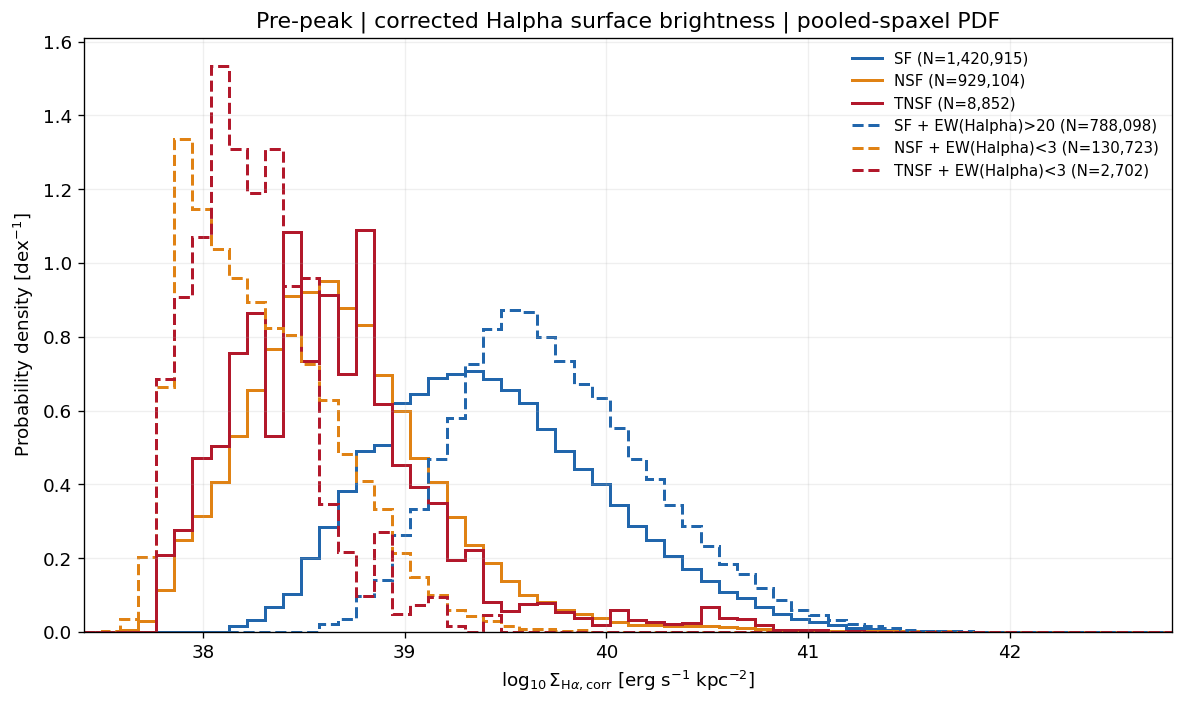

In [6]:
plot_stage_pdf("pre-peak", "Halpha")


Pre-peak | OIII5006_SB | ranges and medians of plotted data
SF: N=1,420,915; galaxies=8; log10 range=[36.0828, 42.1327], median=38.345; linear range=[1.21008e+36, 1.35731e+42], median=2.21293e+38
NSF: N=923,230; galaxies=8; log10 range=[33.8008, 41.7731], median=37.9602; linear range=[6.3208e+33, 5.93094e+41], median=9.12425e+37
TNSF: N=8,852; galaxies=5; log10 range=[37.4563, 41.7577], median=38.3133; linear range=[2.8594e+37, 5.72399e+41], median=2.05709e+38
SF + EW(Halpha)>20: N=788,098; galaxies=8; log10 range=[36.6539, 42.1327], median=38.5989; linear range=[4.5073e+36, 1.35731e+42], median=3.9713e+38
NSF + EW(Halpha)<3: N=130,238; galaxies=5; log10 range=[33.8008, 40.3409], median=37.7517; linear range=[6.3208e+33, 2.19246e+40], median=5.6451e+37
TNSF + EW(Halpha)<3: N=2,702; galaxies=4; log10 range=[37.4563, 39.6743], median=37.9468; linear range=[2.8594e+37, 4.72349e+39], median=8.84619e+37


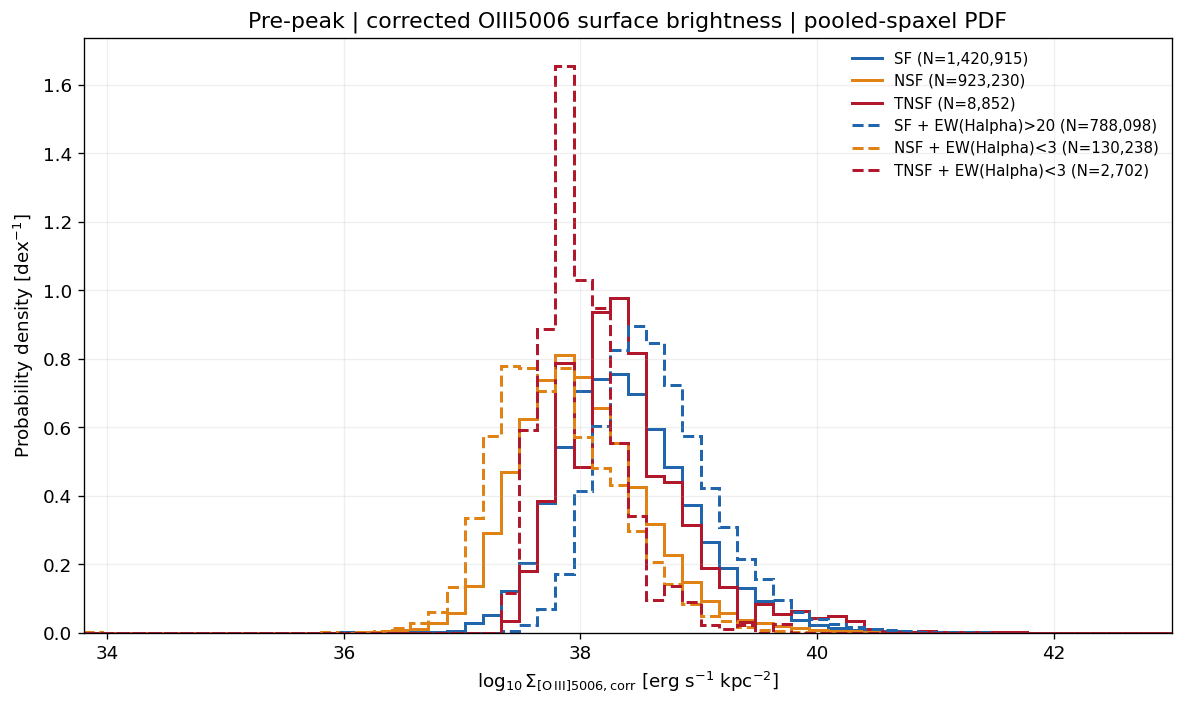

In [7]:
plot_stage_pdf("pre-peak", "OIII5006_SB")


Pre-peak | NII6583_SB | ranges and medians of plotted data
SF: N=1,420,915; galaxies=8; log10 range=[37.3993, 41.5542], median=38.9332; linear range=[2.50811e+37, 3.58249e+41], median=8.57494e+38
NSF: N=929,104; galaxies=8; log10 range=[37.0197, 41.9065], median=38.397; linear range=[1.04645e+37, 8.06264e+41], median=2.49441e+38
TNSF: N=8,852; galaxies=5; log10 range=[37.8472, 41.3766], median=38.6539; linear range=[7.03435e+37, 2.38003e+41], median=4.50679e+38
SF + EW(Halpha)>20: N=788,098; galaxies=8; log10 range=[37.5783, 41.5542], median=39.1833; linear range=[3.78716e+37, 3.58249e+41], median=1.52518e+39
NSF + EW(Halpha)<3: N=130,723; galaxies=5; log10 range=[37.2715, 40.3593], median=38.1792; linear range=[1.86847e+37, 2.28711e+40], median=1.51082e+38
TNSF + EW(Halpha)<3: N=2,702; galaxies=4; log10 range=[37.8741, 39.4321], median=38.3226; linear range=[7.48262e+37, 2.70489e+39], median=2.10188e+38


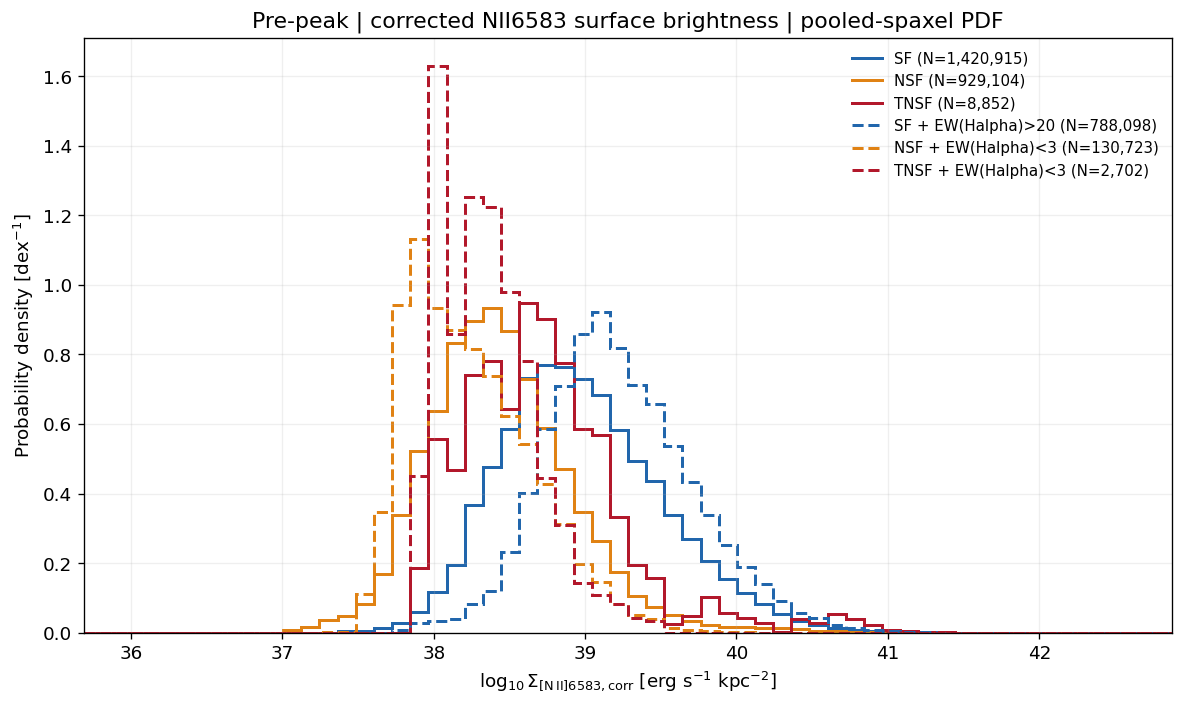

In [8]:
plot_stage_pdf("pre-peak", "NII6583_SB")


Pre-peak | SII_SUM_SB | ranges and medians of plotted data
SF: N=1,420,915; galaxies=8; log10 range=[37.7481, 41.3542], median=38.884; linear range=[5.59944e+37, 2.26023e+41], median=7.65612e+38
NSF: N=929,091; galaxies=8; log10 range=[37.1709, 41.5386], median=38.3558; linear range=[1.48216e+37, 3.45637e+41], median=2.26905e+38
TNSF: N=8,852; galaxies=5; log10 range=[37.7773, 40.8283], median=38.471; linear range=[5.98875e+37, 6.73431e+40], median=2.9581e+38
SF + EW(Halpha)>20: N=788,098; galaxies=8; log10 range=[38.1298, 41.3542], median=39.1213; linear range=[1.34834e+38, 2.26023e+41], median=1.32226e+39
NSF + EW(Halpha)<3: N=130,710; galaxies=5; log10 range=[37.1709, 40.008], median=37.9966; linear range=[1.48216e+37, 1.01855e+40], median=9.92184e+37
TNSF + EW(Halpha)<3: N=2,702; galaxies=4; log10 range=[37.7773, 39.1325], median=38.1344; linear range=[5.98875e+37, 1.35673e+39], median=1.36269e+38


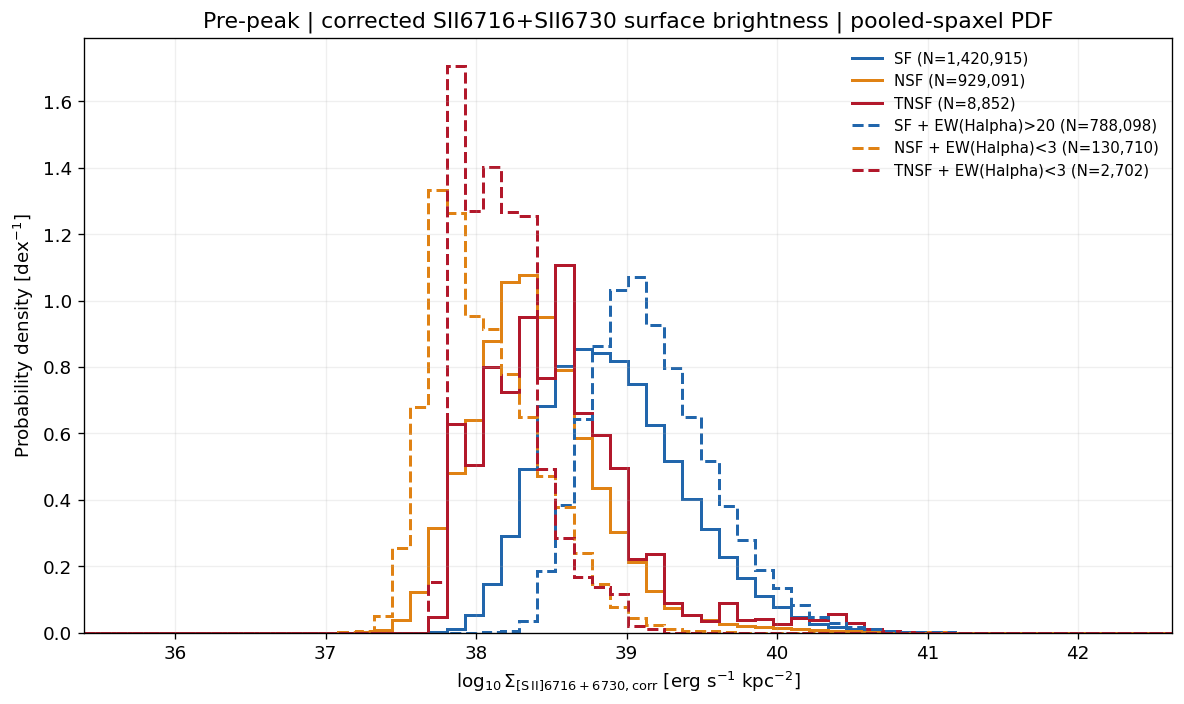

In [9]:
plot_stage_pdf("pre-peak", "SII_SUM_SB")


Pre-peak | O3 | ranges and medians of plotted data
SF: N=1,420,915; galaxies=8; log10 range=[-2.39588, 0.554886], median=-0.603076; linear range=[0.00401906, 3.58828], median=0.249416
NSF: N=923,230; galaxies=8; log10 range=[-3.86405, 0.94254], median=-0.237061; linear range=[0.000136758, 8.76072], median=0.579347
TNSF: N=8,852; galaxies=5; log10 range=[-0.0921671, 0.94254], median=0.181463; linear range=[0.808785, 8.76072], median=1.51867
SF + EW(Halpha)>20: N=788,098; galaxies=8; log10 range=[-2.39588, 0.554886], median=-0.666912; linear range=[0.00401906, 3.58828], median=0.215322
NSF + EW(Halpha)<3: N=130,238; galaxies=5; log10 range=[-3.86405, 0.768506], median=-0.0348277; linear range=[0.000136758, 5.86821], median=0.922937
TNSF + EW(Halpha)<3: N=2,702; galaxies=4; log10 range=[-0.0237936, 0.757121], median=0.181463; linear range=[0.946687, 5.71638], median=1.51867


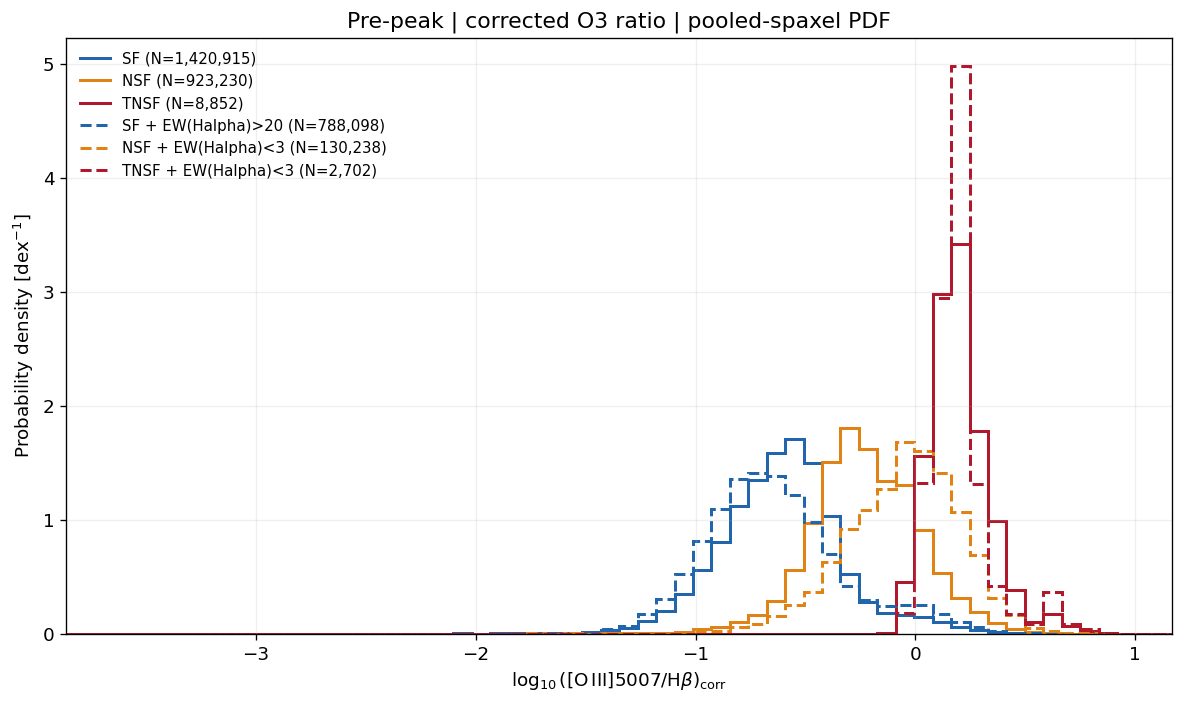

In [10]:
plot_stage_pdf("pre-peak", "O3")


Pre-peak | N2 | ranges and medians of plotted data
SF: N=1,420,915; galaxies=8; log10 range=[-1.23906, -0.206147], median=-0.454618; linear range=[0.0576682, 0.62209], median=0.351061
NSF: N=929,104; galaxies=8; log10 range=[-1.10173, 0.316024], median=-0.237373; linear range=[0.0791173, 2.07025], median=0.578931
TNSF: N=8,852; galaxies=5; log10 range=[-0.353802, 0.316024], median=0.0758755; linear range=[0.44279, 2.07025], median=1.1909
SF + EW(Halpha)>20: N=788,098; galaxies=8; log10 range=[-1.23906, -0.229038], median=-0.495435; linear range=[0.0576682, 0.590149], median=0.319569
NSF + EW(Halpha)<3: N=130,723; galaxies=5; log10 range=[-0.947292, 0.310667], median=-0.0567199; linear range=[0.112904, 2.04488], median=0.877567
TNSF + EW(Halpha)<3: N=2,702; galaxies=4; log10 range=[-0.353802, 0.264289], median=0.102907; linear range=[0.44279, 1.83776], median=1.26738


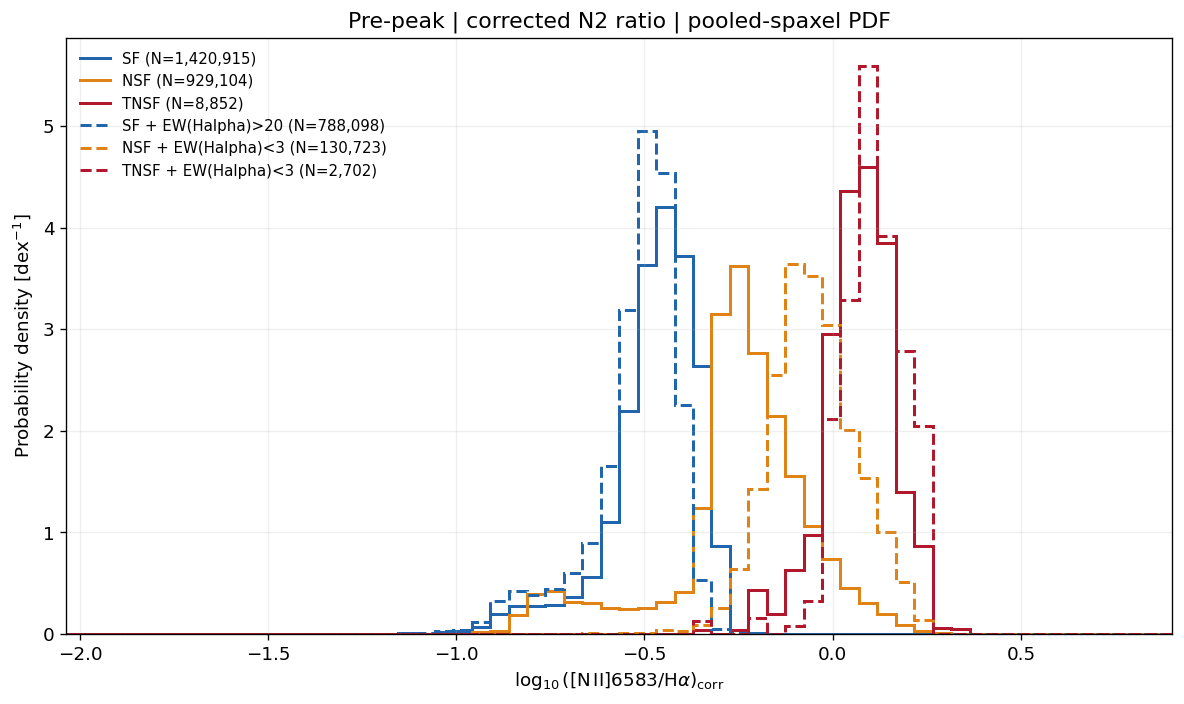

In [11]:
plot_stage_pdf("pre-peak", "N2")


Pre-peak | S2 | ranges and medians of plotted data
SF: N=1,420,915; galaxies=8; log10 range=[-1.22966, -0.113984], median=-0.516374; linear range=[0.0589311, 0.769158], median=0.304527
NSF: N=929,091; galaxies=8; log10 range=[-1.38133, 0.398809], median=-0.285683; linear range=[0.0415596, 2.50501], median=0.517985
TNSF: N=8,852; galaxies=5; log10 range=[-0.649789, 0.0759481], median=-0.105164; linear range=[0.223981, 1.1911], median=0.78494
SF + EW(Halpha)>20: N=788,098; galaxies=8; log10 range=[-1.22966, -0.175687], median=-0.573543; linear range=[0.0589311, 0.667287], median=0.266967
NSF + EW(Halpha)<3: N=130,710; galaxies=5; log10 range=[-0.748216, 0.398809], median=-0.234485; linear range=[0.17856, 2.50501], median=0.582794
TNSF + EW(Halpha)<3: N=2,702; galaxies=4; log10 range=[-0.457381, 0.0689523], median=-0.0935943; linear range=[0.348834, 1.17207], median=0.806131


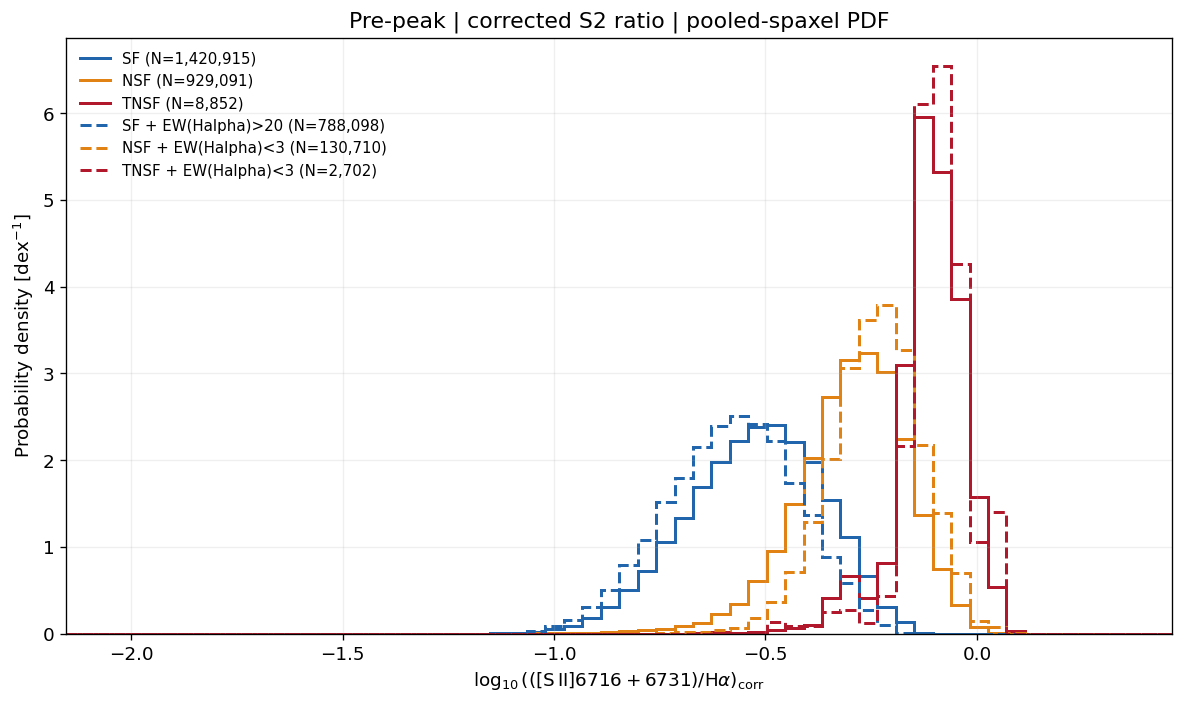

In [12]:
plot_stage_pdf("pre-peak", "S2")

## Close-to-peak distributions


Close-to-peak | Halpha | ranges and medians of plotted data
SF: N=720,842; galaxies=5; log10 range=[37.9322, 41.9699], median=39.3957; linear range=[8.55469e+37, 9.32942e+41], median=2.48695e+39
NSF: N=488,865; galaxies=5; log10 range=[37.4237, 41.7404], median=38.7191; linear range=[2.653e+37, 5.50094e+41], median=5.23693e+38
TNSF: N=6,217; galaxies=5; log10 range=[37.8345, 41.2572], median=38.7095; linear range=[6.8309e+37, 1.80804e+41], median=5.12259e+38
SF + EW(Halpha)>20: N=292,542; galaxies=5; log10 range=[38.5241, 41.9699], median=39.7012; linear range=[3.34243e+38, 9.32942e+41], median=5.02546e+39
NSF + EW(Halpha)<3: N=97,038; galaxies=5; log10 range=[37.4237, 40.8494], median=38.5005; linear range=[2.653e+37, 7.07045e+40], median=3.16593e+38
TNSF + EW(Halpha)<3: N=4,187; galaxies=3; log10 range=[37.8345, 40.5385], median=38.6318; linear range=[6.8309e+37, 3.45515e+40], median=4.28354e+38


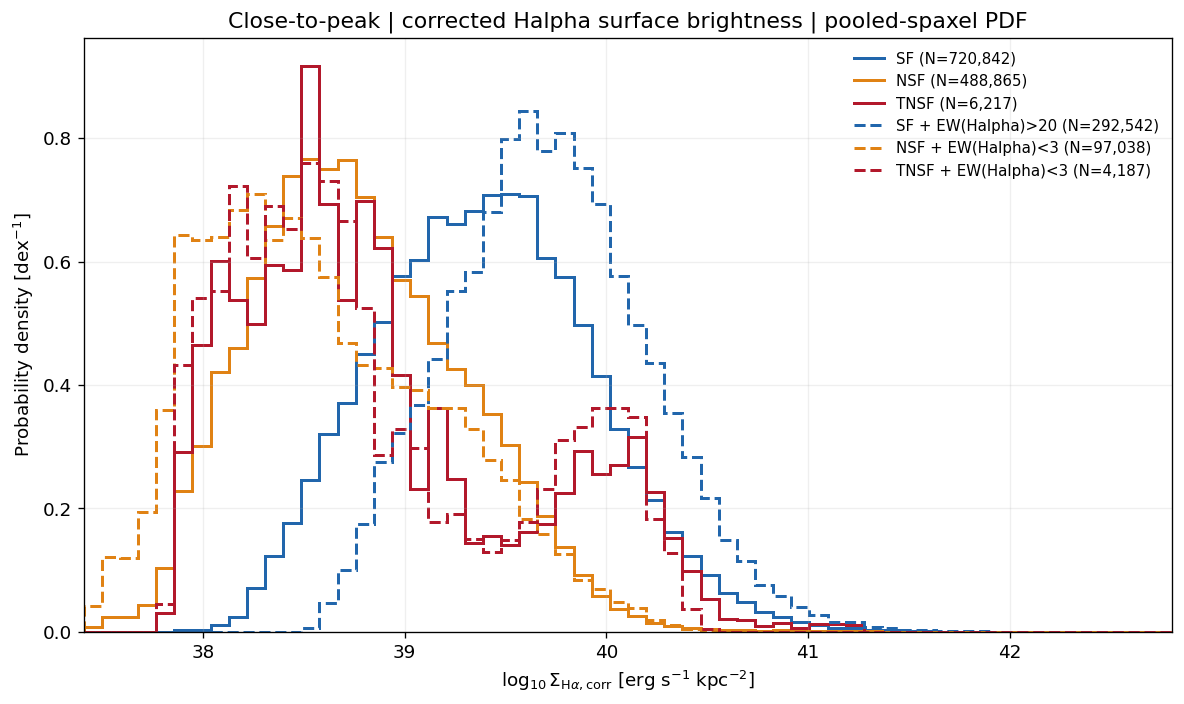

In [13]:
plot_stage_pdf("close-to-peak", "Halpha")


Close-to-peak | OIII5006_SB | ranges and medians of plotted data
SF: N=720,842; galaxies=5; log10 range=[36.3072, 41.4983], median=38.3773; linear range=[2.02874e+36, 3.15015e+41], median=2.38391e+38
NSF: N=486,897; galaxies=5; log10 range=[35.0749, 41.572], median=38.0765; linear range=[1.18823e+35, 3.73276e+41], median=1.19262e+38
TNSF: N=6,217; galaxies=5; log10 range=[37.5202, 41.572], median=38.5343; linear range=[3.31282e+37, 3.73276e+41], median=3.42218e+38
SF + EW(Halpha)>20: N=292,542; galaxies=5; log10 range=[37.1231, 41.4983], median=38.6333; linear range=[1.32763e+37, 3.15015e+41], median=4.29808e+38
NSF + EW(Halpha)<3: N=95,976; galaxies=5; log10 range=[35.0749, 40.9664], median=38.0396; linear range=[1.18823e+35, 9.25644e+40], median=1.09539e+38
TNSF + EW(Halpha)<3: N=4,187; galaxies=3; log10 range=[37.5202, 40.6227], median=38.4178; linear range=[3.31282e+37, 4.19496e+40], median=2.617e+38


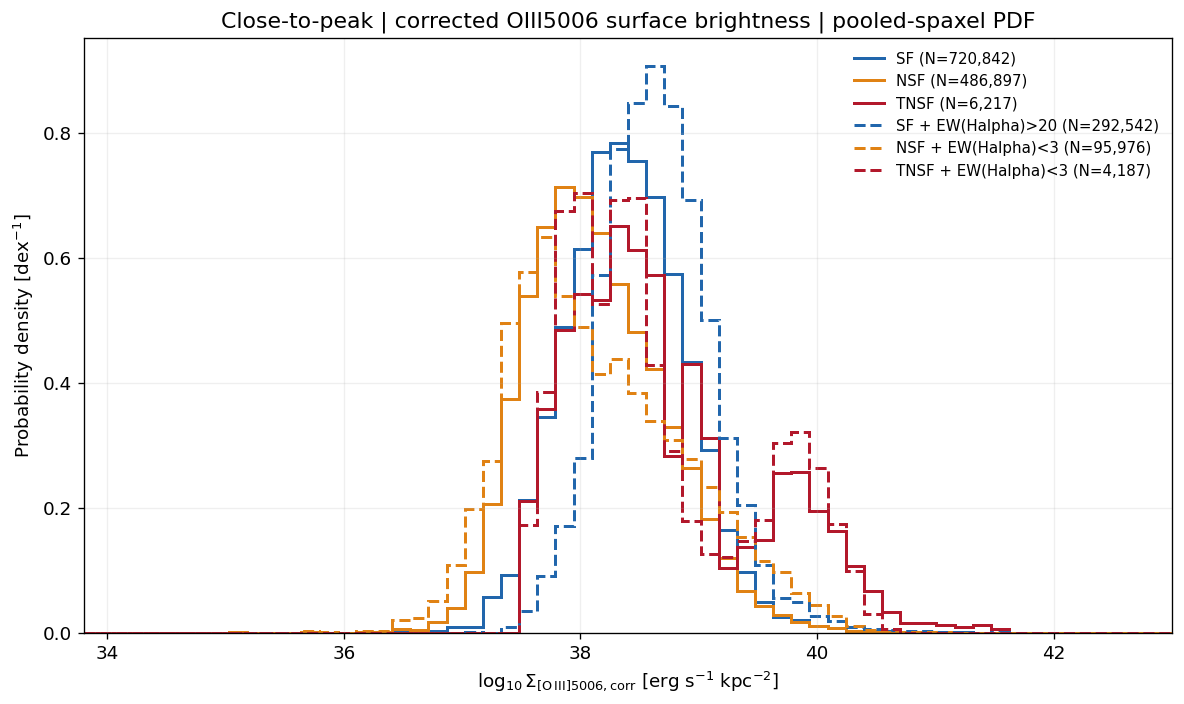

In [14]:
plot_stage_pdf("close-to-peak", "OIII5006_SB")


Close-to-peak | NII6583_SB | ranges and medians of plotted data
SF: N=720,842; galaxies=5; log10 range=[37.5147, 41.5185], median=38.9356; linear range=[3.2709e+37, 3.29997e+41], median=8.62283e+38
NSF: N=488,603; galaxies=5; log10 range=[36.5179, 41.5961], median=38.4861; linear range=[3.29564e+36, 3.94572e+41], median=3.06232e+38
TNSF: N=6,217; galaxies=5; log10 range=[37.8738, 41.5543], median=38.7588; linear range=[7.47891e+37, 3.58323e+41], median=5.73862e+38
SF + EW(Halpha)>20: N=292,542; galaxies=5; log10 range=[37.976, 41.5185], median=39.1763; linear range=[9.46301e+37, 3.29997e+41], median=1.5006e+39
NSF + EW(Halpha)<3: N=96,776; galaxies=5; log10 range=[36.5179, 40.9529], median=38.4112; linear range=[3.29564e+36, 8.97219e+40], median=2.5773e+38
TNSF + EW(Halpha)<3: N=4,187; galaxies=3; log10 range=[37.8738, 40.8455], median=38.7418; linear range=[7.47891e+37, 7.00691e+40], median=5.51877e+38


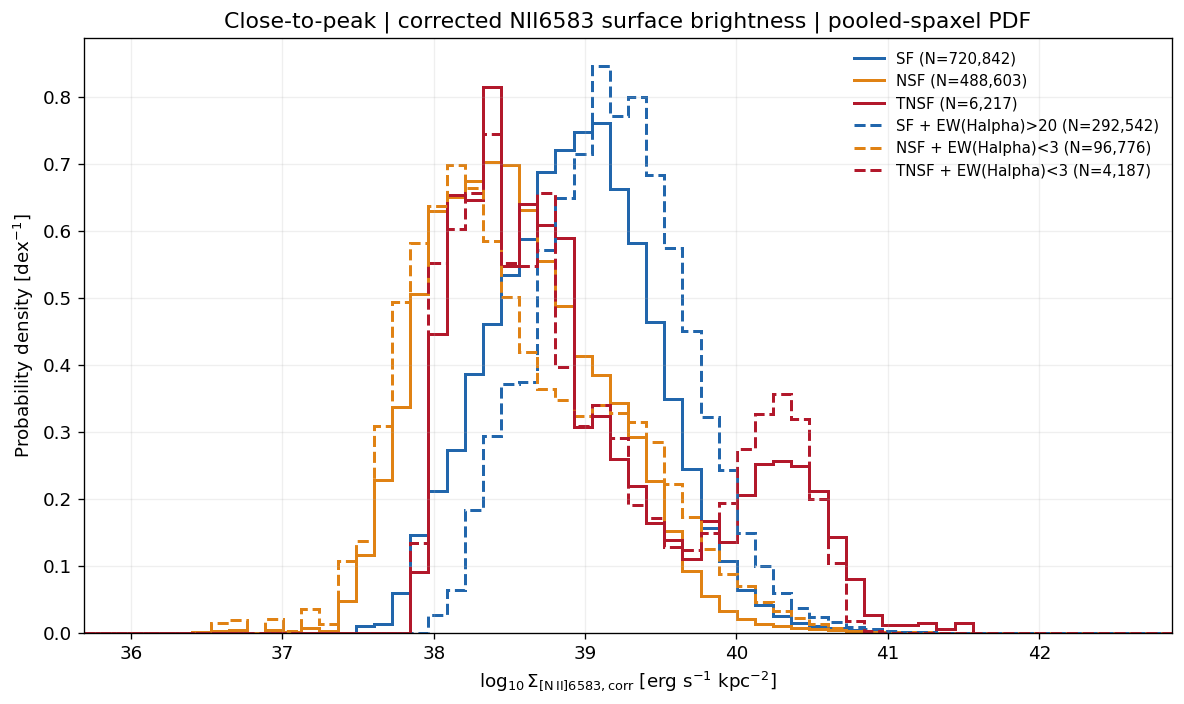

In [15]:
plot_stage_pdf("close-to-peak", "NII6583_SB")


Close-to-peak | SII_SUM_SB | ranges and medians of plotted data
SF: N=720,842; galaxies=5; log10 range=[37.6004, 41.2702], median=38.918; linear range=[3.9849e+37, 1.86301e+41], median=8.27868e+38
NSF: N=488,345; galaxies=5; log10 range=[35.3918, 41.2529], median=38.4962; linear range=[2.46465e+35, 1.79013e+41], median=3.13469e+38
TNSF: N=6,217; galaxies=5; log10 range=[37.7868, 41.1959], median=38.6022; linear range=[6.12021e+37, 1.56985e+41], median=4.00171e+38
SF + EW(Halpha)>20: N=292,542; galaxies=5; log10 range=[38.2125, 41.2702], median=39.166; linear range=[1.63116e+38, 1.86301e+41], median=1.46567e+39
NSF + EW(Halpha)<3: N=96,518; galaxies=5; log10 range=[35.3918, 40.623], median=38.3813; linear range=[2.46465e+35, 4.198e+40], median=2.40614e+38
TNSF + EW(Halpha)<3: N=4,187; galaxies=3; log10 range=[37.7868, 40.5424], median=38.5927; linear range=[6.12021e+37, 3.48693e+40], median=3.9145e+38


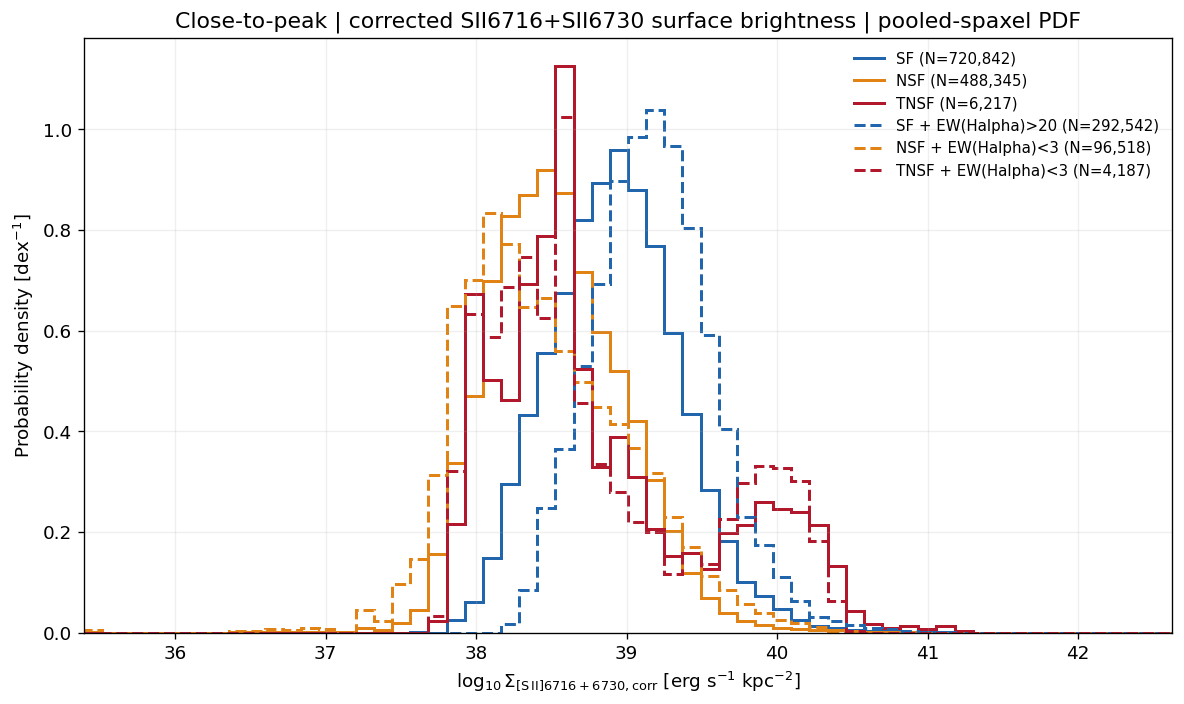

In [16]:
plot_stage_pdf("close-to-peak", "SII_SUM_SB")


Close-to-peak | O3 | ranges and medians of plotted data
SF: N=720,842; galaxies=5; log10 range=[-2.33887, 0.282423], median=-0.549554; linear range=[0.00458282, 1.91612], median=0.282128
NSF: N=486,897; galaxies=5; log10 range=[-2.93036, 0.846801], median=-0.193511; linear range=[0.00117393, 7.0275], median=0.640455
TNSF: N=6,217; galaxies=5; log10 range=[-0.180506, 0.834861], median=0.235461; linear range=[0.659924, 6.83692], median=1.71973
SF + EW(Halpha)>20: N=292,542; galaxies=5; log10 range=[-1.74957, 0.282423], median=-0.638942; linear range=[0.0178003, 1.91612], median=0.229646
NSF + EW(Halpha)<3: N=95,976; galaxies=5; log10 range=[-2.93036, 0.846801], median=0.0122526; linear range=[0.00117393, 7.0275], median=1.02861
TNSF + EW(Halpha)<3: N=4,187; galaxies=3; log10 range=[-0.180506, 0.671524], median=0.233983; linear range=[0.659924, 4.6938], median=1.71389


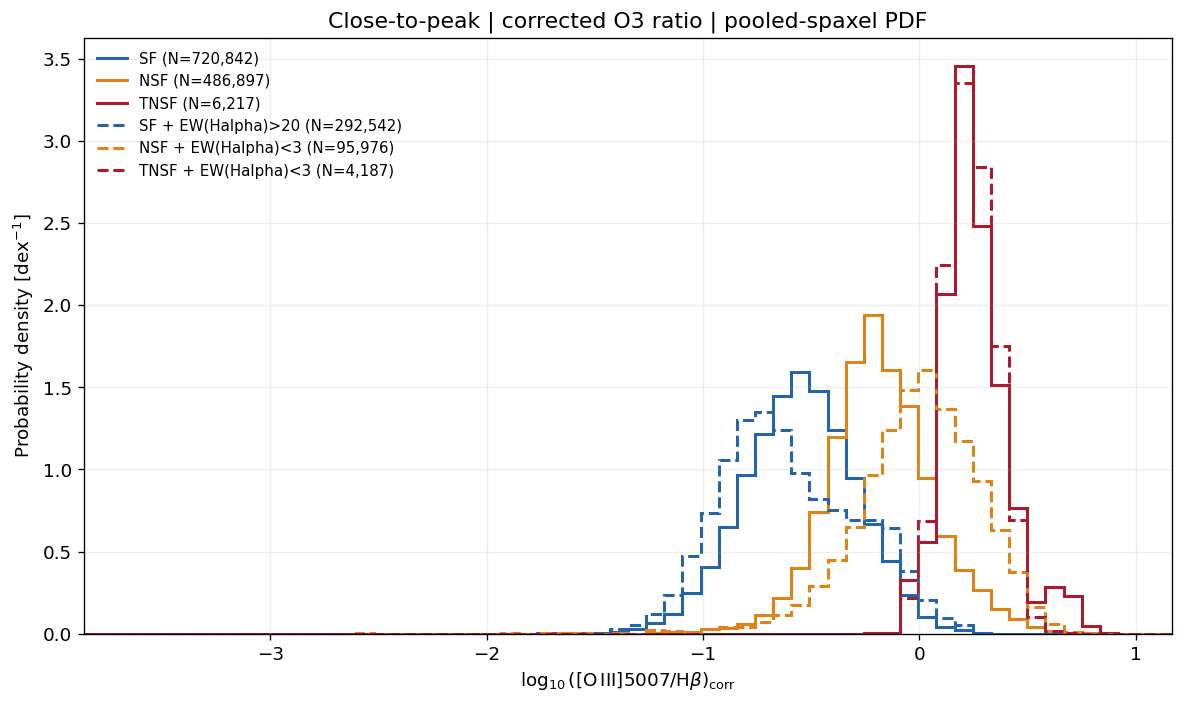

In [17]:
plot_stage_pdf("close-to-peak", "O3")


Close-to-peak | N2 | ranges and medians of plotted data
SF: N=720,842; galaxies=5; log10 range=[-0.837894, -0.233873], median=-0.470324; linear range=[0.145247, 0.583616], median=0.338592
NSF: N=488,603; galaxies=5; log10 range=[-1.15332, 0.455736], median=-0.248409; linear range=[0.070256, 2.85586], median=0.564406
TNSF: N=6,217; galaxies=5; log10 range=[-0.523908, 0.455736], median=0.0886254; linear range=[0.29929, 2.85586], median=1.22638
SF + EW(Halpha)>20: N=292,542; galaxies=5; log10 range=[-0.837894, -0.283401], median=-0.529804; linear range=[0.145247, 0.520714], median=0.295254
NSF + EW(Halpha)<3: N=96,776; galaxies=5; log10 range=[-1.15332, 0.455736], median=-0.060729; linear range=[0.070256, 2.85586], median=0.869503
TNSF + EW(Halpha)<3: N=4,187; galaxies=3; log10 range=[-0.145935, 0.455736], median=0.13542; linear range=[0.714603, 2.85586], median=1.3659


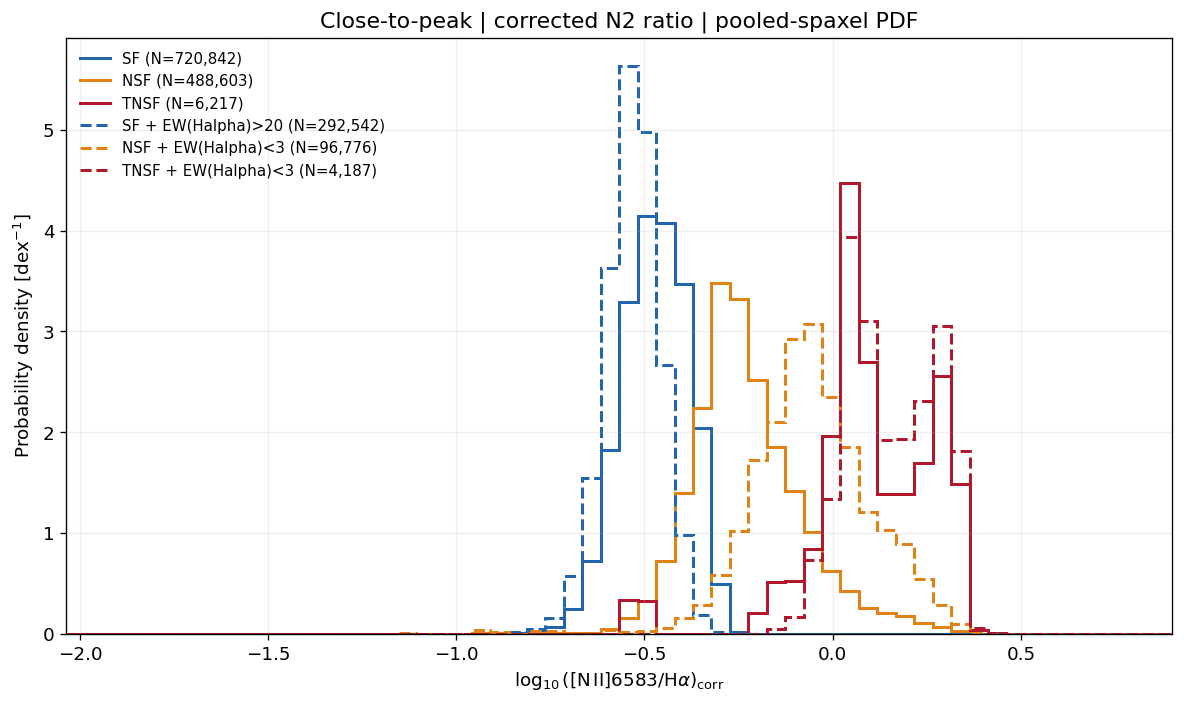

In [18]:
plot_stage_pdf("close-to-peak", "N2")


Close-to-peak | S2 | ranges and medians of plotted data
SF: N=720,842; galaxies=5; log10 range=[-1.14064, -0.117507], median=-0.46795; linear range=[0.0723375, 0.762945], median=0.340447
NSF: N=488,345; galaxies=5; log10 range=[-2.15357, 0.462026], median=-0.226357; linear range=[0.00702148, 2.89752], median=0.593803
TNSF: N=6,217; galaxies=5; log10 range=[-0.377018, 0.217263], median=-0.0570892; linear range=[0.419741, 1.64916], median=0.876821
SF + EW(Halpha)>20: N=292,542; galaxies=5; log10 range=[-1.14064, -0.193041], median=-0.521926; linear range=[0.0723375, 0.641149], median=0.300659
NSF + EW(Halpha)<3: N=96,518; galaxies=5; log10 range=[-2.15357, 0.462026], median=-0.13829; linear range=[0.00702148, 2.89752], median=0.727293
TNSF + EW(Halpha)<3: N=4,187; galaxies=3; log10 range=[-0.377018, 0.217263], median=-0.0426658; linear range=[0.419741, 1.64916], median=0.90643


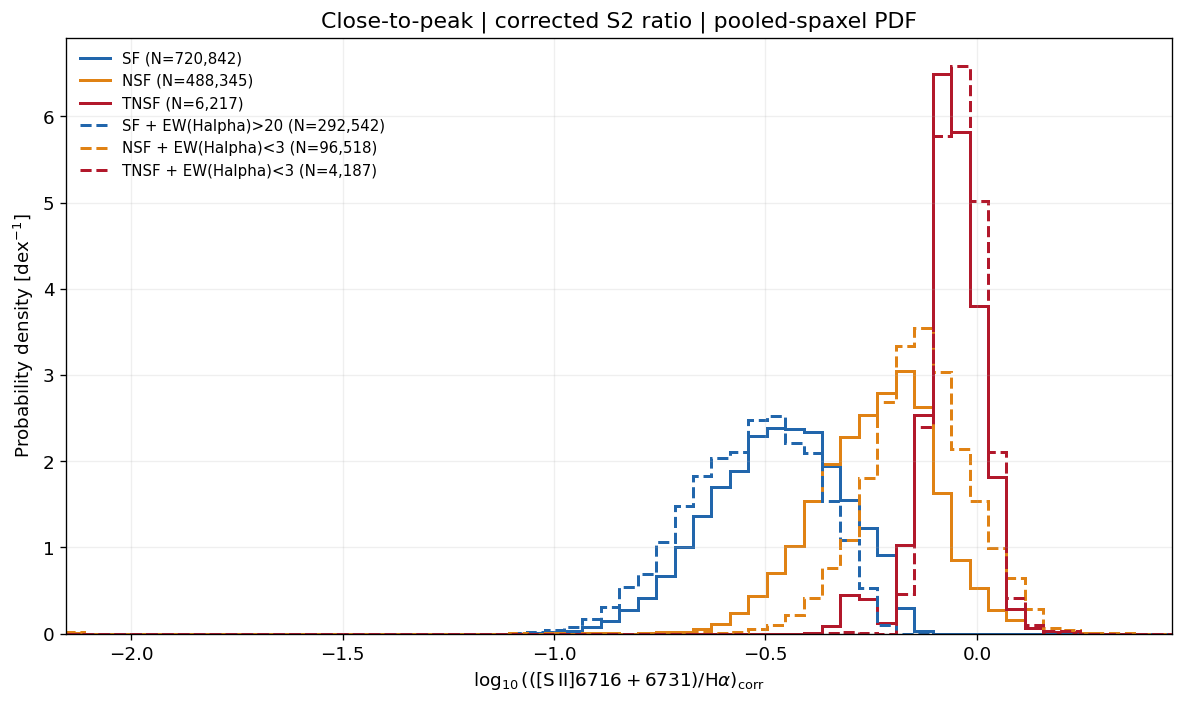

In [19]:
plot_stage_pdf("close-to-peak", "S2")

## Post-peak distributions


Post-peak | Halpha | ranges and medians of plotted data
SF: N=222,427; galaxies=13; log10 range=[38.1172, 42.0925], median=39.3523; linear range=[1.30973e+38, 1.23731e+42], median=2.25052e+39
NSF: N=815,887; galaxies=13; log10 range=[37.4079, 42.8076], median=38.4422; linear range=[2.55822e+37, 6.42125e+42], median=2.76818e+38
TNSF: N=94,780; galaxies=13; log10 range=[37.5922, 42.7973], median=38.3471; linear range=[3.9099e+37, 6.26998e+42], median=2.22378e+38
SF + EW(Halpha)>20: N=61,662; galaxies=13; log10 range=[38.8331, 42.0925], median=39.9303; linear range=[6.80934e+38, 1.23731e+42], median=8.51781e+39
NSF + EW(Halpha)<3: N=500,179; galaxies=13; log10 range=[37.4079, 41.6311], median=38.2534; linear range=[2.55822e+37, 4.27702e+41], median=1.79238e+38
TNSF + EW(Halpha)<3: N=65,260; galaxies=13; log10 range=[37.5922, 40.9938], median=38.2778; linear range=[3.9099e+37, 9.85772e+40], median=1.89581e+38


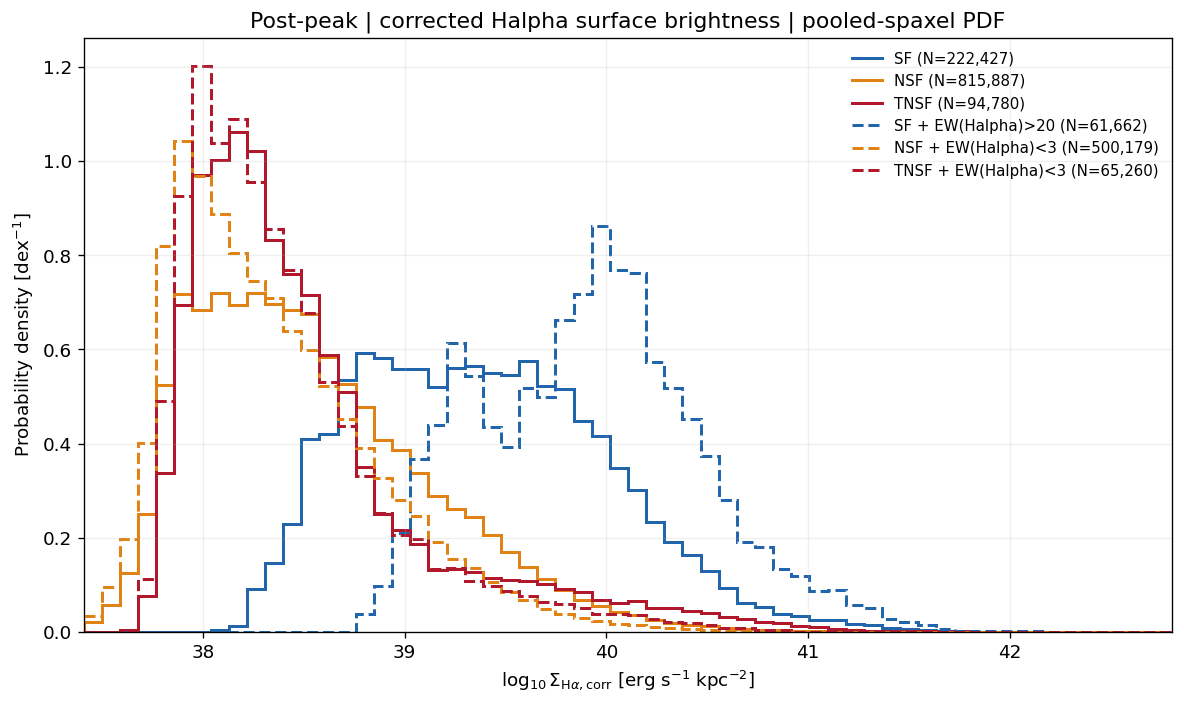

In [20]:
plot_stage_pdf("post-peak", "Halpha")


Post-peak | OIII5006_SB | ranges and medians of plotted data
SF: N=222,427; galaxies=13; log10 range=[35.8896, 40.7219], median=38.2124; linear range=[7.75584e+35, 5.27156e+40], median=1.63071e+38
NSF: N=811,269; galaxies=13; log10 range=[35.2383, 43.0038], median=38.0423; linear range=[1.73113e+35, 1.00872e+43], median=1.10229e+38
TNSF: N=94,780; galaxies=13; log10 range=[37.4125, 43.0038], median=38.1774; linear range=[2.58537e+37, 1.00872e+43], median=1.50437e+38
SF + EW(Halpha)>20: N=61,662; galaxies=13; log10 range=[36.1277, 40.7219], median=38.6232; linear range=[1.34181e+36, 5.27156e+40], median=4.19993e+38
NSF + EW(Halpha)<3: N=498,093; galaxies=13; log10 range=[35.2383, 41.768], median=37.975; linear range=[1.73113e+35, 5.86076e+41], median=9.43969e+37
TNSF + EW(Halpha)<3: N=65,260; galaxies=13; log10 range=[37.4125, 40.7613], median=38.1112; linear range=[2.58537e+37, 5.7711e+40], median=1.29195e+38


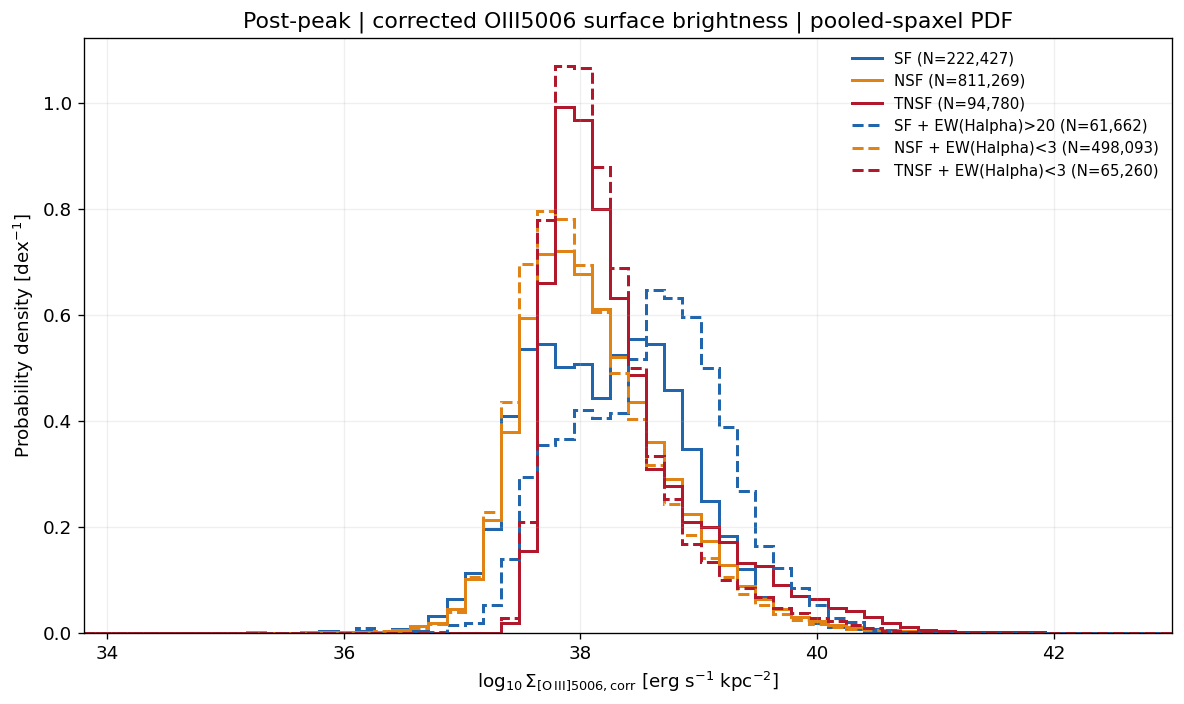

In [21]:
plot_stage_pdf("post-peak", "OIII5006_SB")


Post-peak | NII6583_SB | ranges and medians of plotted data
SF: N=222,427; galaxies=13; log10 range=[37.6465, 41.5797], median=38.8788; linear range=[4.4309e+37, 3.79907e+41], median=7.56499e+38
NSF: N=815,489; galaxies=13; log10 range=[35.6864, 42.88], median=38.3629; linear range=[4.85738e+35, 7.58611e+42], median=2.30627e+38
TNSF: N=94,780; galaxies=13; log10 range=[37.7365, 42.88], median=38.4145; linear range=[5.45126e+37, 7.58611e+42], median=2.59689e+38
SF + EW(Halpha)>20: N=61,662; galaxies=13; log10 range=[38.1416, 41.5797], median=39.3636; linear range=[1.38553e+38, 3.79907e+41], median=2.30984e+39
NSF + EW(Halpha)<3: N=499,781; galaxies=13; log10 range=[35.6864, 41.6844], median=38.2685; linear range=[4.85738e+35, 4.83544e+41], median=1.85586e+38
TNSF + EW(Halpha)<3: N=65,260; galaxies=13; log10 range=[37.7365, 41.0812], median=38.3837; linear range=[5.45126e+37, 1.20553e+41], median=2.41941e+38


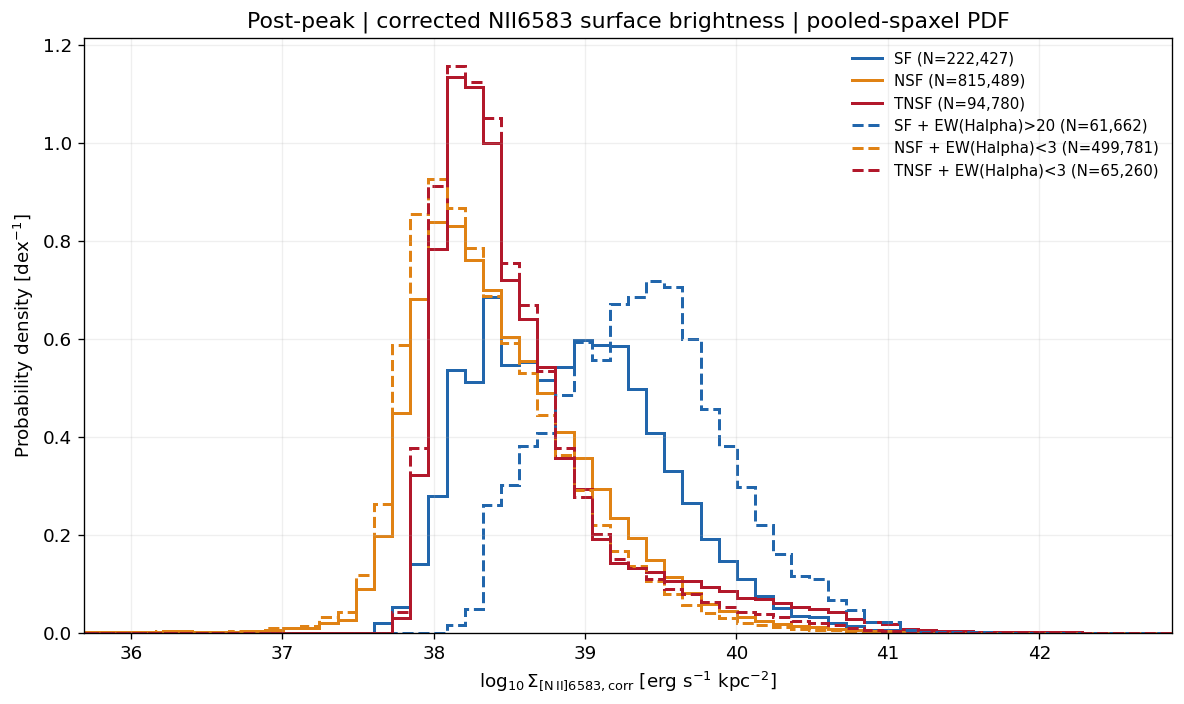

In [22]:
plot_stage_pdf("post-peak", "NII6583_SB")


Post-peak | SII_SUM_SB | ranges and medians of plotted data
SF: N=222,427; galaxies=13; log10 range=[37.6161, 41.2878], median=38.7151; linear range=[4.13137e+37, 1.94018e+41], median=5.18913e+38
NSF: N=810,743; galaxies=13; log10 range=[36.3145, 42.6268], median=38.2467; linear range=[2.06296e+36, 4.23456e+42], median=1.76466e+38
TNSF: N=94,780; galaxies=13; log10 range=[37.7197, 42.6268], median=38.3092; linear range=[5.2448e+37, 4.23456e+42], median=2.03804e+38
SF + EW(Halpha)>20: N=61,662; galaxies=13; log10 range=[38.0569, 41.2878], median=39.2087; linear range=[1.14004e+38, 1.94018e+41], median=1.61698e+39
NSF + EW(Halpha)<3: N=495,717; galaxies=13; log10 range=[36.3145, 41.4713], median=38.1429; linear range=[2.06296e+36, 2.95983e+41], median=1.38971e+38
TNSF + EW(Halpha)<3: N=65,260; galaxies=13; log10 range=[37.7197, 40.9921], median=38.2785; linear range=[5.2448e+37, 9.82052e+40], median=1.89871e+38


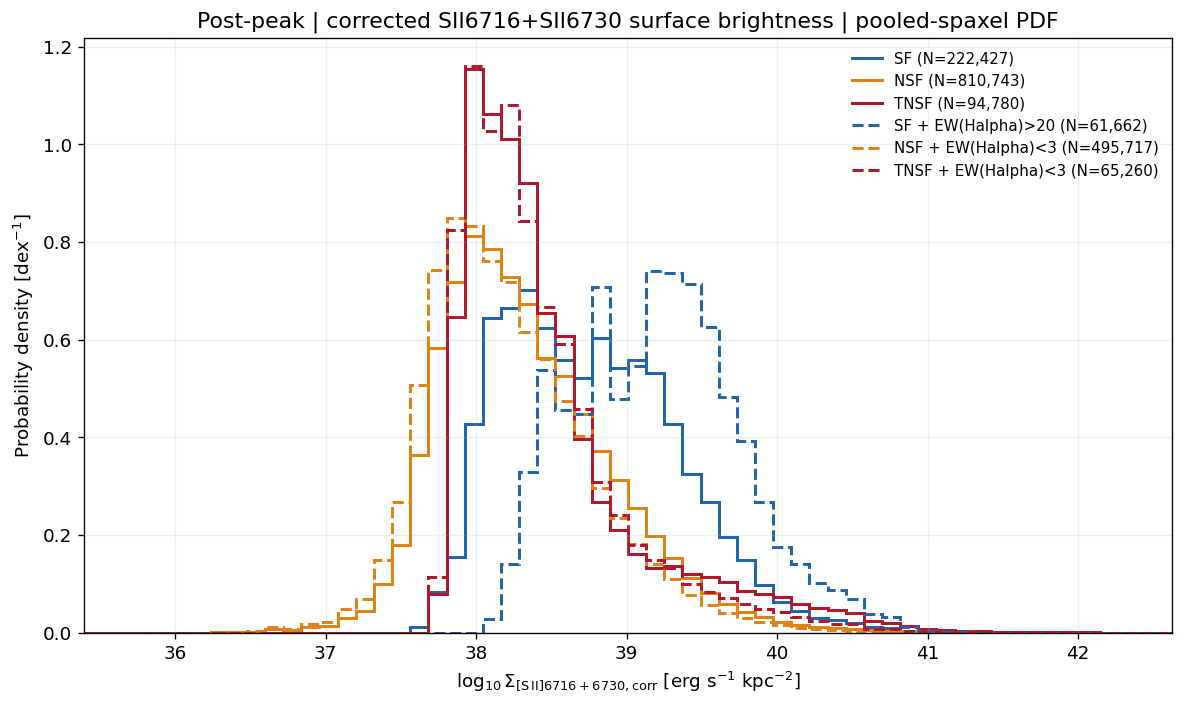

In [23]:
plot_stage_pdf("post-peak", "SII_SUM_SB")


Post-peak | O3 | ranges and medians of plotted data
SF: N=222,427; galaxies=13; log10 range=[-2.60065, 0.105936], median=-0.683935; linear range=[0.00250812, 1.27625], median=0.207045
NSF: N=811,269; galaxies=13; log10 range=[-3.46679, 1.16971], median=0.049779; linear range=[0.000341355, 14.7811], median=1.12145
TNSF: N=94,780; galaxies=13; log10 range=[-0.252255, 1.16971], median=0.25353; linear range=[0.559429, 14.7811], median=1.79279
SF + EW(Halpha)>20: N=61,662; galaxies=13; log10 range=[-2.60065, 0.059359], median=-0.881817; linear range=[0.00250812, 1.14646], median=0.131275
NSF + EW(Halpha)<3: N=498,093; galaxies=13; log10 range=[-2.25635, 1.12445], median=0.142725; linear range=[0.00554178, 13.3184], median=1.38907
TNSF + EW(Halpha)<3: N=65,260; galaxies=13; log10 range=[-0.252255, 0.983422], median=0.247384; linear range=[0.559429, 9.62548], median=1.7676


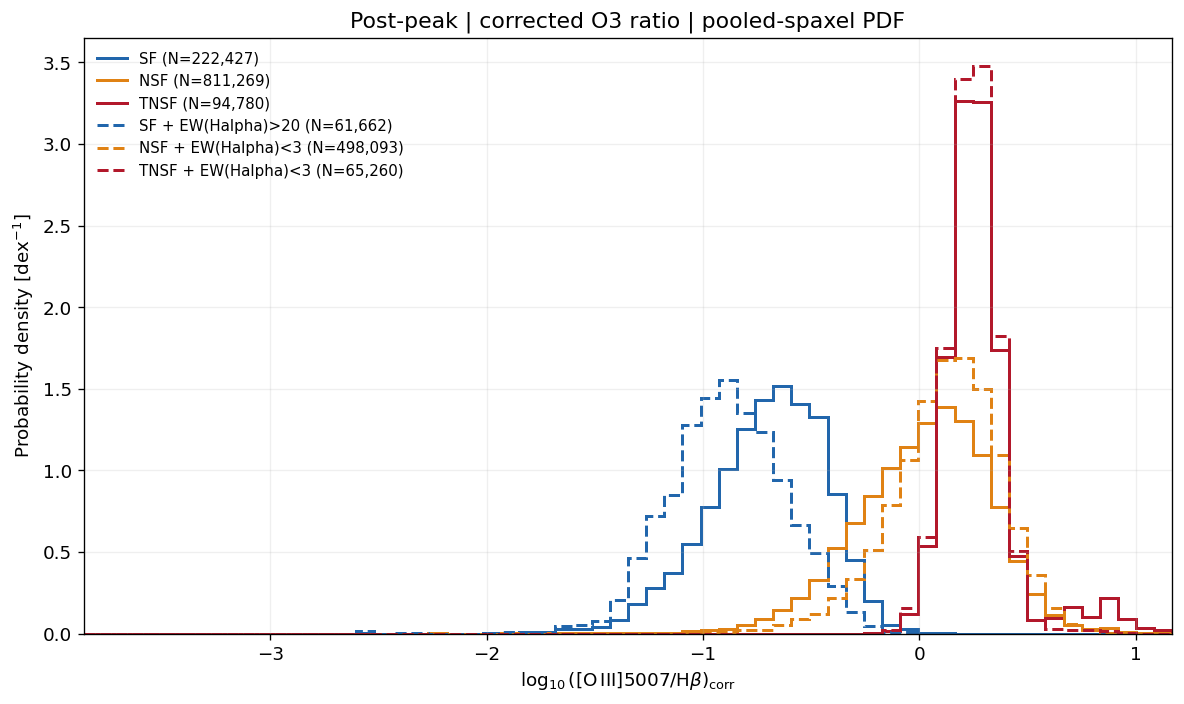

In [24]:
plot_stage_pdf("post-peak", "O3")


Post-peak | N2 | ranges and medians of plotted data
SF: N=222,427; galaxies=13; log10 range=[-1.03267, -0.231202], median=-0.47199; linear range=[0.0927525, 0.587216], median=0.337295
NSF: N=815,489; galaxies=13; log10 range=[-2.03665, 0.902431], median=-0.0505449; linear range=[0.00919082, 7.98787], median=0.890133
TNSF: N=94,780; galaxies=13; log10 range=[-0.302621, 0.571421], median=0.0881248; linear range=[0.498172, 3.72753], median=1.22497
SF + EW(Halpha)>20: N=61,662; galaxies=13; log10 range=[-1.03267, -0.277374], median=-0.540894; linear range=[0.0927525, 0.52799], median=0.28781
NSF + EW(Halpha)<3: N=499,781; galaxies=13; log10 range=[-2.02304, 0.902431], median=0.0205921; linear range=[0.00948337, 7.98787], median=1.04856
TNSF + EW(Halpha)<3: N=65,260; galaxies=13; log10 range=[-0.302621, 0.571421], median=0.104807; linear range=[0.498172, 3.72753], median=1.27294


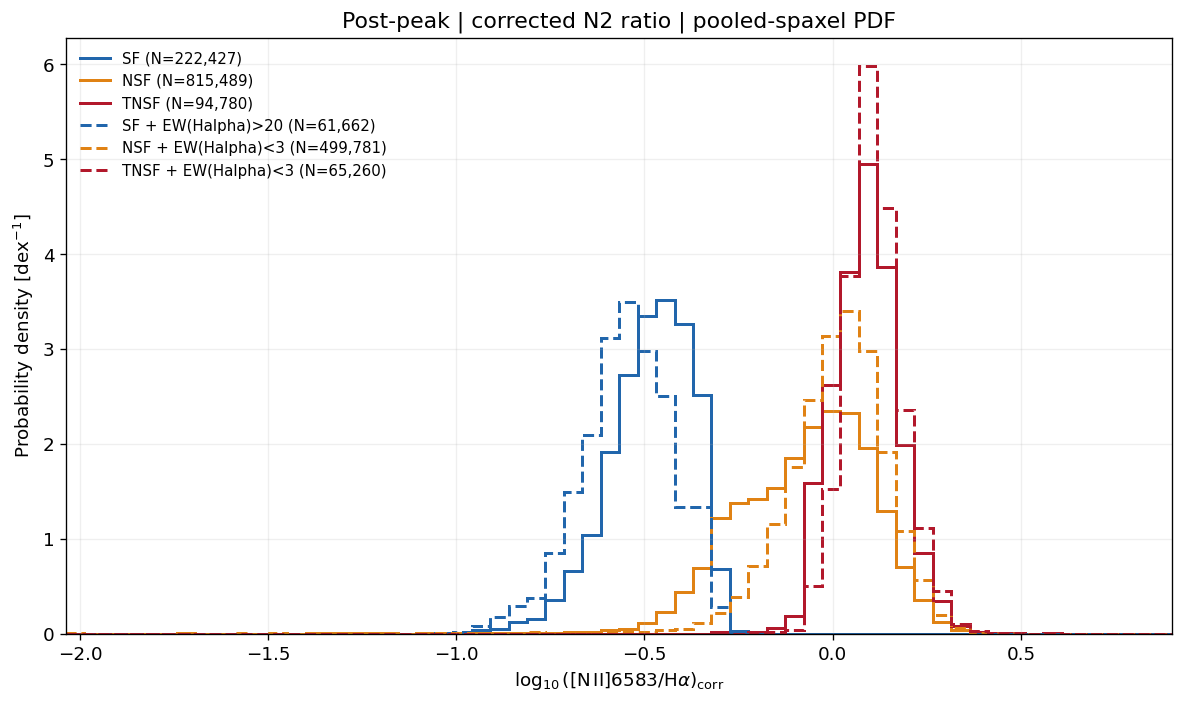

In [25]:
plot_stage_pdf("post-peak", "N2")


Post-peak | S2 | ranges and medians of plotted data
SF: N=222,427; galaxies=13; log10 range=[-1.19513, -0.223488], median=-0.618226; linear range=[0.0638075, 0.59774], median=0.240865
NSF: N=810,743; galaxies=13; log10 range=[-1.8706, 0.370517], median=-0.184716; linear range=[0.013471, 2.34702], median=0.653558
TNSF: N=94,780; galaxies=13; log10 range=[-0.492621, 0.370517], median=-0.0225378; linear range=[0.321647, 2.34702], median=0.949428
SF + EW(Halpha)>20: N=61,662; galaxies=13; log10 range=[-1.19513, -0.328204], median=-0.710334; linear range=[0.0638075, 0.469674], median=0.194835
NSF + EW(Halpha)<3: N=495,717; galaxies=13; log10 range=[-1.51949, 0.370517], median=-0.120805; linear range=[0.0302352, 2.34702], median=0.757173
TNSF + EW(Halpha)<3: N=65,260; galaxies=13; log10 range=[-0.415176, 0.370517], median=0.00727332; linear range=[0.384436, 2.34702], median=1.01689


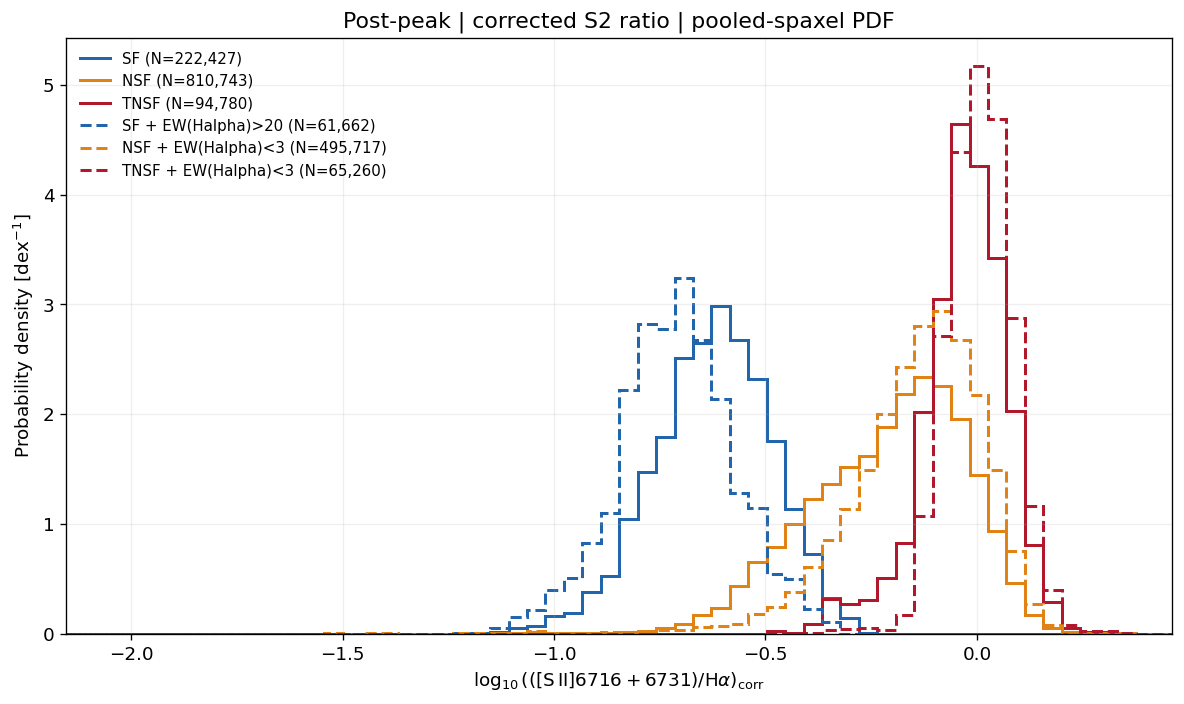

In [26]:
plot_stage_pdf("post-peak", "S2")

## Numerical summary and checks

All 126 stage/observable/catalogue combinations are retained below, including empty distributions. PDF integrals are computed over the full common edges; finite contributor counts distinguish measured distributions from the parent catalogue footprint.

In [27]:
PDF_SUMMARY = pd.DataFrame(PDF_SUMMARY_ROWS)
assert len(PDF_SUMMARY) == len(STAGE_ORDER) * len(OBSERVABLE_ORDER) * len(CATEGORY_ORDER)
assert not PDF_SUMMARY.duplicated(["stage", "observable", "category"]).any()
assert all(HISTOGRAM_CHECKS)
nonempty = PDF_SUMMARY.N_spaxel.gt(0)
assert np.allclose(PDF_SUMMARY.loc[nonempty, "PDF_integral"], 1)
assert (MEASUREMENT_COUNTS.N_finite <= MEASUREMENT_COUNTS.N_selected).all()
assert MEASUREMENT_COUNTS.N_selected.eq(MEASUREMENT_COUNTS.N_finite + MEASUREMENT_COUNTS.N_unavailable).all()
assert MEASUREMENT_COUNTS.groupby(["GALID", "category"]).N_selected.nunique().eq(1).all()
assert (PDF_SUMMARY.loc[nonempty, "log10_min"] <= PDF_SUMMARY.loc[nonempty, "log10_median"]).all()
assert (PDF_SUMMARY.loc[nonempty, "log10_median"] <= PDF_SUMMARY.loc[nonempty, "log10_max"]).all()
display(PDF_SUMMARY)
print("CORRECTED_HALPHA_BPT_STAGE_PDF_VALIDATION_OK: 21 figures; 126 distributions")


,stage,observable,category,N_spaxel,N_galaxies,log10_min,log10_max,log10_median,linear_min,linear_max,linear_median,PDF_integral
0,pre-peak,Halpha,SF,1420915,8,38.037550,42.267389,39.401395,1.090311e+38,1.850927e+42,2.519970e+39,1.0
1,pre-peak,Halpha,NSF,929104,8,37.540863,42.234075,38.639274,3.474263e+37,1.714253e+42,4.357864e+38,1.0
2,pre-peak,Halpha,TNSF,8852,5,37.795061,41.271525,38.594620,6.238224e+37,1.868638e+41,3.932055e+38,1.0
3,pre-peak,Halpha,SF + EW(Halpha)>20,788098,8,38.594339,42.267389,39.693174,3.929511e+38,1.850927e+42,4.933709e+39,1.0
4,pre-peak,Halpha,NSF + EW(Halpha)<3,130723,5,37.540863,40.292859,38.235578,3.474263e+37,1.962725e+40,1.720198e+38,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
121,post-peak,S2,NSF,810743,13,-1.870601,0.370517,-0.184716,1.347097e-02,2.347022e+00,6.535585e-01,1.0
122,post-peak,S2,TNSF,94780,13,-0.492621,0.370517,-0.022538,3.216466e-01,2.347022e+00,9.494283e-01,1.0
123,post-peak,S2,SF + EW(Halpha)>20,61662,13,-1.195128,-0.328204,-0.710334,6.380748e-02,4.696735e-01,1.948345e-01,1.0
124,post-peak,S2,NSF + EW(Halpha)<3,495717,13,-1.519486,0.370517,-0.120805,3.023525e-02,2.347022e+00,7.571731e-01,1.0


CORRECTED_HALPHA_BPT_STAGE_PDF_VALIDATION_OK: 21 figures; 126 distributions
